# MIMIC-IV Derived Concepts Showcase

This notebook explores the **`mimiciv_derived`** schema — the ~65 derived concept
tables built by **step 17** of `build_mimic.py` (`postgres-make-concepts.sql` from
[MIT-LCP/mimic-code](https://github.com/MIT-LCP/mimic-code)).

Each section explains the **clinical purpose** of a concept category, runs a
representative query, and displays the result.

## Prerequisites
- `mimic_postgres` container running (steps 1–5 of `build_mimic.py`)
- `mimiciv_hosp` / `mimiciv_icu` / `mimiciv_ed` loaded (steps 6–15)
- `mimiciv_derived` concepts built (steps 16–17)

## Sections
0. [Overview — all derived tables](#0.-Overview)
1. [Demographics & ICU Stays](#1.-Demographics-&-ICU-Stays)
2. [Severity Scores](#2.-Severity-Scores)
3. [Sepsis-3](#3.-Sepsis-3)
4. [Blood Gas Measurements](#4.-Blood-Gas-Measurements)
5. [Vital Signs](#5.-Vital-Signs)
6. [Glasgow Coma Scale](#6.-Glasgow-Coma-Scale)
7. [Acute Kidney Injury (KDIGO)](#7.-Acute-Kidney-Injury)
8. [Vasopressor Agents](#8.-Vasopressor-Agents)
9. [Antibiotics](#9.-Antibiotics)
10. [Charlson Comorbidity Index](#10.-Charlson-Comorbidity-Index)
11. [First-Day Summary Tables](#11.-First-Day-Summary-Tables)
12. [Septic Shock Cohort Example](#12.-Septic-Shock-Cohort-Example)

---
## Setup — connection and display helpers

In [1]:
import os
import pandas as pd
import psycopg
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from dotenv import load_dotenv
from IPython.display import display

load_dotenv()

POSTGRES_HOST     = os.environ.get('POSTGRES_HOST',     'localhost')
POSTGRES_PORT     = int(os.environ.get('POSTGRES_PORT', '5432'))
POSTGRES_DB       = os.environ.get('POSTGRES_DB',       'mimiciv')
POSTGRES_USER     = os.environ.get('POSTGRES_USER',     'mimicuser')
POSTGRES_PASSWORD = os.environ.get('POSTGRES_PASSWORD', 'mimicpass')

conn = psycopg.connect(
    host=POSTGRES_HOST, port=POSTGRES_PORT,
    dbname=POSTGRES_DB, user=POSTGRES_USER,
    password=POSTGRES_PASSWORD,
    autocommit=True,
)

def q(sql: str, limit: int = 10) -> pd.DataFrame:
    """Run SQL and return a DataFrame. Skips gracefully if table missing."""
    try:
        with conn.cursor() as cur:
            cur.execute(sql)
            rows = cur.fetchall()
            cols = [desc[0] for desc in cur.description] if cur.description else []
        return pd.DataFrame(rows, columns=cols).head(limit)
    except Exception as e:
        print(f'[SKIP] {str(e).split(chr(10))[0]}')
        conn.rollback()
        return pd.DataFrame()

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'Connected to {POSTGRES_DB} at {POSTGRES_HOST}:{POSTGRES_PORT}')

Matplotlib is building the font cache; this may take a moment.


Connected to mimiciv at localhost:5432


---
## 0. Overview

List every table in `mimiciv_derived` with its row count and disk size.
A count of **0** means the concept built but produced no rows — common with
a row-limited load where some referenced patients are absent.

In [2]:
overview_sql = """
    SELECT
        table_name,
        pg_size_pretty(pg_total_relation_size(
            quote_ident(table_schema) || '.' || quote_ident(table_name)
        )) AS size_on_disk
    FROM information_schema.tables
    WHERE table_schema = 'mimiciv_derived'
      AND table_type   = 'BASE TABLE'
    ORDER BY table_name
"""
try:
    df_overview = q(overview_sql, limit=1000)
    counts = []
    for tbl in df_overview['table_name']:
        try:
            with conn.cursor() as cur:
                cur.execute(f'SELECT COUNT(*) FROM mimiciv_derived.{tbl}')
                counts.append(cur.fetchone()[0])
        except Exception:
            conn.rollback()
            counts.append(None)
    df_overview.insert(1, 'row_count', counts)
    display(df_overview)
    print(f'\nTotal concept tables: {len(df_overview)}')
except Exception as e:
    print(f'[SKIP] {e}')

,table_name,row_count,size_on_disk
0,acei,135153,9248 kB
1,age,546028,36 MB
2,antibiotic,949901,69 MB
3,apsiii,94458,11 MB
4,bg,697418,91 MB
...,...,...,...
58,vasopressin,37163,2592 kB
59,ventilation,144813,11 MB
60,ventilator_setting,1377514,142 MB
61,vitalsign,13519533,1252 MB



Total concept tables: 63


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Section 0 visualisation ────────────────────────────────────────────────
# Horizontal bar chart: row counts per derived concept table
# Tables are grouped by clinical category and colour-coded so the chart
# doubles as a visual index of the schema.

if not df_overview.empty and 'row_count' in df_overview.columns:
    df_plot = df_overview.dropna(subset=['row_count']).copy()
    df_plot['row_count'] = df_plot['row_count'].astype(float)

    # ── Assign a colour group by clinical domain ──────────────────────────
    def _domain(name: str) -> str:
        if name.startswith('first_day'):   return 'First-day summaries'
        if 'kdigo' in name:                return 'AKI / KDIGO'
        if name in ('sofa', 'sapsii', 'oasis', 'apsiii', 'lods', 'sirs',
                    'first_day_sofa'):     return 'Severity scores'
        if name in ('sepsis3', 'suspicion_of_infection'): return 'Sepsis-3'
        if name.startswith('bg') or name in ('oxygen_delivery',): return 'Blood gas'
        if 'vaso' in name or 'norepinephrine' in name: return 'Vasopressors'
        if name in ('antibiotic',):        return 'Antibiotics'
        if name in ('charlson',):          return 'Comorbidities'
        if name in ('icustay_detail', 'icustay_times', 'icustay_hourly',
                    'age', 'weight_durations'): return 'Demographics'
        if 'gcs' in name:                  return 'GCS'
        if name in ('vitalsign',):         return 'Vital signs'
        return 'Other'

    df_plot['domain'] = df_plot['table_name'].apply(_domain)

    domains   = df_plot['domain'].unique()
    # matplotlib 3.7+: use matplotlib.colormaps instead of plt.cm.get_cmap
    cmap      = matplotlib.colormaps.get_cmap('tab20').resampled(len(domains))
    color_map = {d: cmap(i) for i, d in enumerate(domains)}
    colors    = df_plot['domain'].map(color_map)

    # Sort by row count descending for readability
    df_plot = df_plot.sort_values('row_count', ascending=True)
    colors  = df_plot['domain'].map(color_map)

    fig, ax = plt.subplots(figsize=(10, max(6, len(df_plot) * 0.28)))
    bars = ax.barh(df_plot['table_name'], df_plot['row_count'],
                   color=colors, edgecolor='white', linewidth=0.4)

    # Annotate every bar with the human-readable count
    for bar, val in zip(bars, df_plot['row_count']):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{int(val):,}', va='center', ha='left', fontsize=7)

    # Legend for domains
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=color_map[d], label=d) for d in sorted(color_map)]
    ax.legend(handles=handles, loc='lower right', fontsize=7,
              title='Clinical domain', title_fontsize=8, framealpha=0.8)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{int(x):,}'))
    ax.set_xlabel('Row count (log scale)', fontsize=9)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_title('Row counts across all mimiciv_derived concept tables\n'
                 '(symlog scale — zero-count tables visible at left edge)',
                 fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print('[SKIP] df_overview not available')

---
## 1. Demographics & ICU Stays

**`icustay_detail`** combines patient demographics (age, sex, ethnicity) with
hospital and ICU admission metadata into a single convenience table.
It is the standard **starting point for cohort selection**: filter by
admission type, age range, care unit, or ICU length of stay.

Related tables:
- `icustay_times` — ICU in/out times (input to all hourly concepts)
- `icustay_hourly` — one row per stay per hour (the time grid)
- `age` — patient age at each admission
- `weight_durations` — time-varying body weight for dose normalisation

In [4]:
# One row per ICU stay — demographics + admission metadata
# icustay_detail does not carry careunit — use icu_intime/icu_outtime for timing
display(q("""
    SELECT subject_id, hadm_id, stay_id, gender,
           ROUND(admission_age::numeric, 1) AS age_yrs,
           ROUND(los_icu::numeric, 2)       AS icu_los_days,
           hospital_expire_flag,
           first_icu_stay
    FROM mimiciv_derived.icustay_detail
    ORDER BY stay_id
"""))

,subject_id,hadm_id,stay_id,gender,age_yrs,icu_los_days,hospital_expire_flag,first_icu_stay
0,12466550,23998182,30000153,M,61.7,1.64,0,True
1,13180007,27543152,30000213,M,66.5,1.64,0,True
2,18421337,22413411,30000484,M,92.0,2.48,0,True
3,12207593,22795209,30000646,M,44.3,4.70,1,True
4,15726459,22744101,30000831,M,78.3,2.71,0,True
5,12980335,23552849,30001148,M,68.7,1.14,0,True
6,12168737,29283664,30001336,M,77.2,2.78,0,True
7,17371178,24502166,30001396,M,40.8,1.17,0,True
8,16513856,24463832,30001446,M,56.3,1.66,0,True
9,17461994,29537385,30001471,M,91.3,3.38,0,True


In [5]:
# Age distribution — ICU cohorts are typically skewed toward older adults
display(q("""
    SELECT
        width_bucket(admission_age, 18, 100, 8) * 10 + 8 AS age_bucket_start,
        COUNT(*) AS n_stays
    FROM mimiciv_derived.icustay_detail
    WHERE admission_age >= 18
    GROUP BY 1
    ORDER BY 1
""", limit=20))

,age_bucket_start,n_stays
0,18,2983
1,28,4805
2,38,7206
3,48,15082
4,58,22553
5,68,21405
6,78,15593
7,88,4815
8,98,16


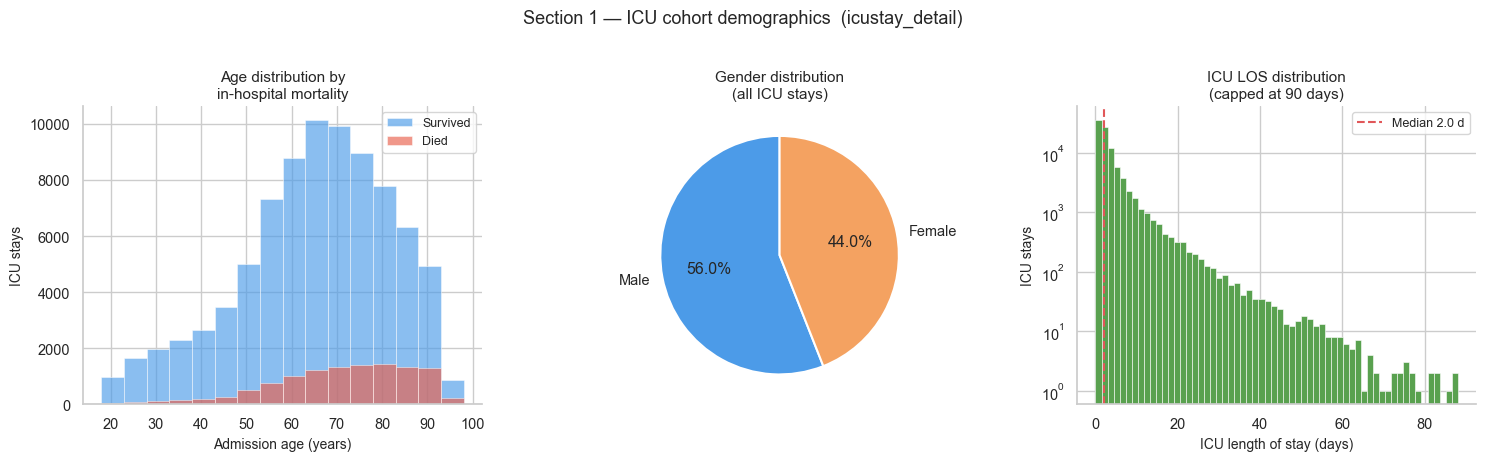

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Section 1 visualisations ───────────────────────────────────────────────
# (a) Age distribution histogram coloured by in-hospital mortality
# (b) Gender breakdown pie chart
# (c) ICU LOS distribution (days) — log scale to show the heavy right tail

df_age_mort = q("""
    SELECT
        ROUND(admission_age::numeric, 0) AS age,
        gender,
        ROUND(los_icu::numeric, 2)       AS los_icu,
        hospital_expire_flag             AS died
    FROM mimiciv_derived.icustay_detail
    WHERE admission_age IS NOT NULL
""", limit=200_000)

if df_age_mort.empty:
    print('[SKIP] icustay_detail empty')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # ── (a) Age histogram by mortality ────────────────────────────────────
    ax = axes[0]
    for died, label, color in [(0, 'Survived', '#4C9BE8'), (1, 'Died', '#E8604C')]:
        subset = df_age_mort[df_age_mort['died'] == died]['age'].dropna()
        ax.hist(subset, bins=range(18, 101, 5), alpha=0.65, label=label,
                color=color, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Admission age (years)', fontsize=10)
    ax.set_ylabel('ICU stays', fontsize=10)
    ax.set_title('Age distribution by\nin-hospital mortality', fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) Gender pie chart ───────────────────────────────────────────────
    ax = axes[1]
    gender_counts = df_age_mort['gender'].value_counts()
    labels_map = {'M': 'Male', 'F': 'Female'}
    pie_labels  = [labels_map.get(g, g) for g in gender_counts.index]
    ax.pie(gender_counts.values, labels=pie_labels,
           autopct='%1.1f%%', startangle=90,
           colors=['#4C9BE8', '#F4A261'],
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title('Gender distribution\n(all ICU stays)', fontsize=11)

    # ── (c) ICU LOS distribution ───────────────────────────────────────────
    ax = axes[2]
    los = df_age_mort['los_icu'].dropna()
    los = los[(los > 0) & (los < 90)]  # clip extreme outliers for display
    ax.hist(los, bins=60, color='#59A14F', edgecolor='white', linewidth=0.4)
    ax.axvline(los.median(), color='#E15759', linewidth=1.5,
               linestyle='--', label=f'Median {los.median():.1f} d')
    ax.set_xlabel('ICU length of stay (days)', fontsize=10)
    ax.set_ylabel('ICU stays', fontsize=10)
    ax.set_title('ICU LOS distribution\n(capped at 90 days)', fontsize=11)
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 1 — ICU cohort demographics  (icustay_detail)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 2. Severity Scores

Severity scores summarise illness severity at ICU admission using combinations
of vital signs, labs, and clinical data. They are widely used as **covariates
in regression models** and for **risk-adjusted outcome comparisons**.

| Table | Grain | Key use |
|-------|-------|--------|
| `sofa` | hourly | Time-series organ failure; Sepsis-3 criterion |
| `first_day_sofa` | per stay | 24-h SOFA for admission severity |
| `sapsii` | per stay | Admission mortality prediction (17 variables) |
| `oasis` | per stay | Admission mortality (10 vars, no labs required) |
| `apsiii` | per stay | APACHE III score |
| `lods` | per stay | Logistic Organ Dysfunction Score |
| `sirs` | per stay | Systemic Inflammatory Response Syndrome |

In [7]:
# SOFA — hourly, one row per (stay_id, hr)
# 6 organ systems scored 0–4 each; total 0–24
display(q("""
    SELECT stay_id, hr, sofa_24hours AS sofa_24h,
           respiration, coagulation, liver,
           cardiovascular, cns, renal
    FROM mimiciv_derived.sofa
    WHERE hr BETWEEN 0 AND 23
    ORDER BY stay_id, hr
""", limit=12))

,stay_id,hr,sofa_24h,respiration,coagulation,liver,cardiovascular,cns,renal
0,30000153,0,0,NaN,NaN,NaN,0.000,0.000,NaN
1,30000153,1,0,0.000,NaN,NaN,0.000,NaN,NaN
2,30000153,2,0,0.000,NaN,NaN,NaN,NaN,NaN
3,30000153,3,0,NaN,0.000,NaN,0.000,NaN,0.000
4,30000153,4,0,0.000,NaN,NaN,0.000,0.000,NaN
5,30000153,5,3,NaN,NaN,NaN,0.000,3.000,NaN
6,30000153,6,3,NaN,NaN,NaN,0.000,3.000,NaN
7,30000153,7,3,NaN,NaN,NaN,0.000,2.000,NaN
8,30000153,8,3,NaN,NaN,NaN,0.000,2.000,NaN
9,30000153,9,3,NaN,NaN,NaN,0.000,NaN,NaN


In [8]:
# SAPS II — worst values in first 24 h; score 0–163
# sapsii_prob is the predicted hospital mortality probability
display(q("""
    SELECT stay_id, sapsii, sapsii_prob
    FROM mimiciv_derived.sapsii
    ORDER BY sapsii DESC
"""))

,stay_id,sapsii,sapsii_prob
0,36758013,115,0.996
1,32128372,115,0.996
2,31949871,115,0.996
3,31787232,113,0.995
4,30253505,111,0.994
5,32421370,110,0.994
6,34786631,110,0.994
7,35042608,108,0.992
8,36214732,108,0.992
9,37257840,108,0.992


In [9]:
# Do SAPS II, OASIS, and 24-h SOFA agree directionally?
# first_day_sofa uses column 'sofa' (not 'sofa_24hours')
display(q("""
    SELECT
        ROUND(AVG(s.sapsii), 1)           AS mean_sapsii,
        ROUND(AVG(o.oasis), 1)            AS mean_oasis,
        ROUND(AVG(f.sofa), 1)             AS mean_sofa_24h,
        ROUND(CORR(s.sapsii, o.oasis)::numeric, 3) AS corr_sapsii_oasis,
        ROUND(CORR(s.sapsii, f.sofa)::numeric, 3)  AS corr_sapsii_sofa
    FROM mimiciv_derived.sapsii s
    JOIN mimiciv_derived.oasis o USING (stay_id)
    JOIN mimiciv_derived.first_day_sofa f USING (stay_id)
""", limit=5))

,mean_sapsii,mean_oasis,mean_sofa_24h,corr_sapsii_oasis,corr_sapsii_sofa
0,35.4,30.6,4.4,0.686,0.680


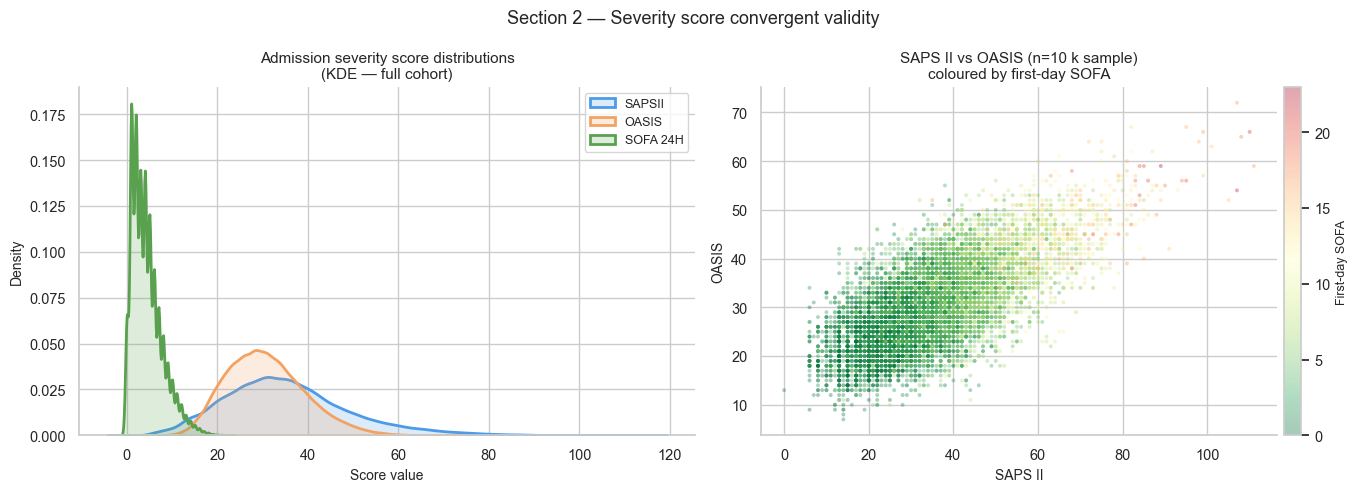

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Section 2 visualisations ───────────────────────────────────────────────
# (a) KDE / distribution curves for SAPS II, OASIS, and first-day SOFA
#     — all three describe the same patients; how well does each spread?
# (b) SAPS II vs OASIS scatter coloured by first-day SOFA
#     — confirms the three scores agree directionally (convergent validity)

df_scores = q("""
    SELECT s.sapsii, o.oasis, f.sofa AS sofa_24h,
           d.hospital_expire_flag AS died
    FROM mimiciv_derived.sapsii s
    JOIN mimiciv_derived.oasis            o USING (stay_id)
    JOIN mimiciv_derived.first_day_sofa   f USING (stay_id)
    JOIN mimiciv_derived.icustay_detail   d USING (stay_id)
    WHERE s.sapsii IS NOT NULL
""", limit=200_000)

if df_scores.empty:
    print('[SKIP] score tables empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (a) KDE distributions ─────────────────────────────────────────────
    ax = axes[0]
    palette = {'sapsii': '#4C9BE8', 'oasis': '#F4A261', 'sofa_24h': '#59A14F'}
    for col, color in palette.items():
        vals = df_scores[col].dropna()
        sns.kdeplot(vals, ax=ax, label=col.upper().replace('_', ' '),
                    color=color, linewidth=2, fill=True, alpha=0.20)
    ax.set_xlabel('Score value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title('Admission severity score distributions\n(KDE — full cohort)',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) SAPS II vs OASIS scatter ──────────────────────────────────────
    ax = axes[1]
    sample = df_scores.sample(min(10_000, len(df_scores)), random_state=42)
    sc = ax.scatter(sample['sapsii'], sample['oasis'],
                    c=sample['sofa_24h'], cmap='RdYlGn_r',
                    alpha=0.35, s=8, linewidths=0)
    cbar = fig.colorbar(sc, ax=ax, pad=0.01)
    cbar.set_label('First-day SOFA', fontsize=9)
    ax.set_xlabel('SAPS II', fontsize=10)
    ax.set_ylabel('OASIS', fontsize=10)
    ax.set_title('SAPS II vs OASIS (n=10 k sample)\ncoloured by first-day SOFA',
                 fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 2 — Severity score convergent validity', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 3. Sepsis-3

The **Sepsis-3** definition (Singer et al., *JAMA* 2016) requires:
1. **Suspected infection** — antibiotics + blood cultures within a ±2-day window
2. **Organ dysfunction** — acute SOFA score increase ≥ 2 from baseline

MIMIC-IV provides both building blocks:
- `suspicion_of_infection` — antibiotic orders matched to blood culture times
- `sepsis3` — final table: one row per ICU stay meeting Sepsis-3 criteria

This enables **reproducible Sepsis-3 cohort construction** without manual chart review.

In [11]:
# sepsis3 — one row per ICU stay meeting Sepsis-3 criteria
display(q("""
    SELECT stay_id, suspected_infection_time,
           sofa_score,
           respiration, cardiovascular, renal, cns
    FROM mimiciv_derived.sepsis3
    ORDER BY stay_id
"""))

,stay_id,suspected_infection_time,sofa_score,respiration,cardiovascular,renal,cns
0,30000484,2136-01-14 18:10:00,3,0,0,0,3
1,30000646,2194-04-29 01:00:00,3,2,1,0,0
2,30000831,2140-04-18 05:11:00,5,0,0,2,3
3,30001446,2186-04-11 08:20:00,8,0,0,2,0
4,30001555,2177-09-27 07:21:00,8,0,0,0,1
5,30002012,2175-09-27 14:00:00,6,0,0,4,0
6,30002415,2126-12-16 15:05:00,4,2,0,0,0
7,30002654,2154-10-17 11:15:00,4,0,4,0,0
8,30002925,2134-06-04 23:17:00,3,0,1,2,0
9,30003226,2123-02-28 08:00:00,4,0,0,4,0


In [12]:
# Prevalence and average organ dysfunction in Sepsis-3 cohort
display(q("""
    SELECT
        COUNT(*)                              AS sepsis3_stays,
        ROUND(AVG(sofa_score)::numeric, 2)    AS mean_sofa,
        ROUND(AVG(respiration)::numeric, 2)   AS mean_respiratory,
        ROUND(AVG(cardiovascular)::numeric, 2) AS mean_cardiovascular,
        ROUND(AVG(renal)::numeric, 2)         AS mean_renal,
        ROUND(AVG(cns)::numeric, 2)           AS mean_cns
    FROM mimiciv_derived.sepsis3
"""))

,sepsis3_stays,mean_sofa,mean_respiratory,mean_cardiovascular,mean_renal,mean_cns
0,41295,3.70,0.56,1.10,0.73,0.49


In [13]:
# suspicion_of_infection — antibiotic + culture timing (intermediate table)
display(q("""
    SELECT stay_id, antibiotic_time, culture_time,
           specimen, positive_culture
    FROM mimiciv_derived.suspicion_of_infection
    ORDER BY stay_id
"""))

,stay_id,antibiotic_time,culture_time,specimen,positive_culture
0,30000484.000,2136-01-15 08:00:00,2136-01-14 18:10:00,URINE,1.000
1,30000484.000,2136-01-15 02:00:00,2136-01-14 18:10:00,URINE,1.000
2,30000484.000,2136-01-15 12:00:00,2136-01-14 18:10:00,URINE,1.000
3,30000484.000,2136-01-15 20:00:00,2136-01-14 18:10:00,URINE,1.000
4,30000484.000,2136-01-15 17:00:00,2136-01-14 18:10:00,URINE,1.000
5,30000484.000,2136-01-15 12:00:00,2136-01-14 18:10:00,URINE,1.000
6,30000484.000,2136-01-14 21:00:00,2136-01-14 18:10:00,URINE,1.000
7,30000484.000,2136-01-14 21:00:00,2136-01-14 18:10:00,URINE,1.000
8,30000484.000,2136-01-14 21:00:00,2136-01-14 18:10:00,URINE,1.000
9,30000484.000,2136-01-15 04:00:00,2136-01-14 18:10:00,URINE,1.000


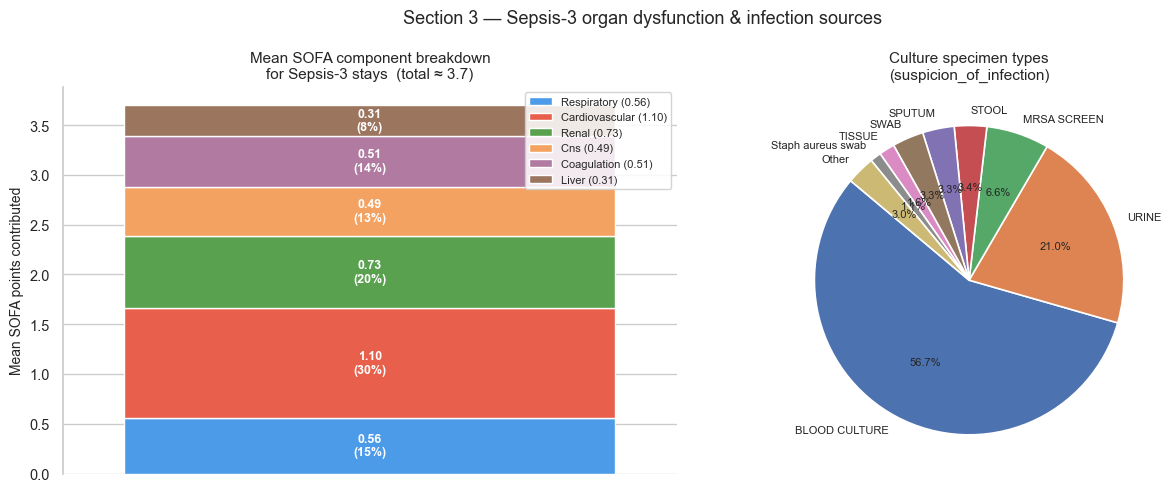

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ── Section 3 visualisations ───────────────────────────────────────────────
# (a) Stacked bar: average SOFA organ-system contribution in Sepsis-3 stays
#     — shows which organ system drives most dysfunction
# (b) Specimen type breakdown for suspected infections
#     — blood cultures dominate; urinary & respiratory also common

df_sep_summary = q("""
    SELECT
        ROUND(AVG(respiration)::numeric, 2)    AS respiratory,
        ROUND(AVG(cardiovascular)::numeric, 2) AS cardiovascular,
        ROUND(AVG(renal)::numeric, 2)          AS renal,
        ROUND(AVG(cns)::numeric, 2)            AS cns,
        ROUND(AVG(coagulation)::numeric, 2)    AS coagulation,
        ROUND(AVG(liver)::numeric, 2)          AS liver
    FROM mimiciv_derived.sepsis3
""", limit=1)

df_specimen = q("""
    SELECT specimen, COUNT(*) AS n
    FROM mimiciv_derived.suspicion_of_infection
    WHERE specimen IS NOT NULL
    GROUP BY specimen
    ORDER BY n DESC
""", limit=12)

if df_sep_summary.empty or df_specimen.empty:
    print('[SKIP] sepsis tables empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── (a) Stacked bar — mean organ SOFA components ─────────────────────
    ax = axes[0]
    organs  = ['respiratory', 'cardiovascular', 'renal', 'cns', 'coagulation', 'liver']
    palette = ['#4C9BE8', '#E8604C', '#59A14F', '#F4A261', '#B07AA1', '#9C755F']
    values  = [float(df_sep_summary[o].iloc[0]) for o in organs]
    total   = sum(values)
    bottom  = 0
    for organ, val, color in zip(organs, values, palette):
        ax.bar(0, val, bottom=bottom, color=color, edgecolor='white',
               linewidth=1, label=f'{organ.title()} ({val:.2f})')
        if val > 0.05:
            ax.text(0, bottom + val / 2,
                    f'{val:.2f}\n({100*val/total:.0f}%)',
                    ha='center', va='center', fontsize=9, color='white',
                    fontweight='bold')
        bottom += val
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylabel('Mean SOFA points contributed', fontsize=10)
    ax.set_title(f'Mean SOFA component breakdown\nfor Sepsis-3 stays  (total ≈ {total:.1f})',
                 fontsize=11)
    ax.set_xticks([])
    ax.legend(loc='upper right', fontsize=8, framealpha=0.85)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # ── (b) Specimen pie ───────────────────────────────────────────────────
    ax = axes[1]
    top_n   = min(8, len(df_specimen))
    labels  = list(df_specimen['specimen'][:top_n])
    counts  = list(df_specimen['n'][:top_n].astype(int))
    if len(df_specimen) > top_n:
        labels.append('Other')
        counts.append(int(df_specimen['n'][top_n:].sum()))
    wedge_props = {'edgecolor': 'white', 'linewidth': 1.2}
    ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140,
           wedgeprops=wedge_props, textprops={'fontsize': 8})
    ax.set_title('Culture specimen types\n(suspicion_of_infection)', fontsize=11)

    fig.suptitle('Section 3 — Sepsis-3 organ dysfunction & infection sources',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 4. Blood Gas Measurements

**`bg`** pivots arterial blood gas (ABG) lab results from `labevents` into a
wide-format table — one row per specimen, with ~20 named analyte columns.

Key analytes:

| Column | Clinical meaning |
|--------|------------------|
| `ph` | Acid-base balance (normal 7.35–7.45) |
| `po2` (PaO₂) | Arterial oxygen tension (normal 80–100 mmHg) |
| `pco2` (PaCO₂) | CO₂ clearance (normal 35–45 mmHg) |
| `pf_ratio` | PaO₂/FiO₂ — ARDS severity criterion |
| `bicarbonate` | Metabolic acid-base buffer |
| `baseexcess` | Metabolic component of acid-base |
| `lactate` | Tissue hypoperfusion marker |

Using `bg` avoids the complexity of directly querying `labevents` with item ID lists.

In [15]:
# Arterial blood gas values — keyed on (subject_id, hadm_id, charttime)
# bg has no stay_id; join to icustay_detail via hadm_id when stay_id is needed
display(q("""
    SELECT subject_id, hadm_id, charttime, specimen,
           ROUND(ph::numeric, 2)          AS ph,
           ROUND(po2::numeric, 1)         AS pao2_mmhg,
           ROUND(pco2::numeric, 1)        AS paco2_mmhg,
           ROUND(bicarbonate::numeric, 1) AS hco3,
           ROUND(baseexcess::numeric, 1)  AS base_excess,
           ROUND(lactate::numeric, 2)     AS lactate,
           ROUND(glucose::numeric, 1)     AS glucose
    FROM mimiciv_derived.bg
    WHERE specimen = 'ART.'
    ORDER BY subject_id, charttime
"""))

,subject_id,hadm_id,charttime,specimen,ph,pao2_mmhg,paco2_mmhg,hco3,base_excess,lactate,glucose
0,10000690,NaN,2150-11-02 19:05:00,ART.,7.32,123.0,54.0,None,0.0,None,None
1,10000690,25860671.000,2150-11-08 05:43:00,ART.,7.45,68.0,52.0,None,9.0,None,None
2,10000935,25849114.000,2187-10-22 15:40:00,ART.,7.41,86.0,33.0,None,-2.0,2.80,None
3,10001884,26184834.000,2131-01-10 13:15:00,ART.,7.42,72.0,49.0,None,5.0,2.00,None
4,10001884,26184834.000,2131-01-11 03:42:00,ART.,7.22,74.0,94.0,None,6.0,None,None
5,10001884,26184834.000,2131-01-12 21:04:00,ART.,7.38,65.0,60.0,None,7.0,1.10,None
6,10001884,26184834.000,2131-01-13 02:28:00,ART.,7.42,69.0,53.0,None,7.0,1.20,None
7,10001884,26184834.000,2131-01-14 07:05:00,ART.,7.46,91.0,49.0,None,9.0,None,None
8,10002013,23581541.000,2160-05-18 09:19:00,ART.,7.33,441.0,49.0,None,0.0,2.30,332.0
9,10002013,23581541.000,2160-05-18 10:26:00,ART.,7.35,421.0,45.0,None,0.0,3.30,216.0


In [16]:
# P:F ratio (pao2fio2ratio) distribution — Berlin ARDS severity categories
# P:F < 300 = mild ARDS; < 200 = moderate; < 100 = severe
display(q("""
    SELECT
        CASE
            WHEN pao2fio2ratio < 100  THEN '< 100  (severe ARDS)'
            WHEN pao2fio2ratio < 200  THEN '100-200 (moderate ARDS)'
            WHEN pao2fio2ratio < 300  THEN '200-300 (mild ARDS)'
            ELSE                           '>= 300  (no ARDS)'
        END AS pf_category,
        COUNT(*) AS n_specimens
    FROM mimiciv_derived.bg
    WHERE pao2fio2ratio IS NOT NULL
      AND specimen = 'ART.'
    GROUP BY 1
    ORDER BY 1
""", limit=10))

,pf_category,n_specimens
0,100-200 (moderate ARDS),110292
1,< 100 (severe ARDS),23673
2,200-300 (mild ARDS),106703
3,>= 300 (no ARDS),96343


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Section 4 visualisations ───────────────────────────────────────────────
# (a) P:F ratio distribution with Berlin ARDS threshold lines
#     — teaching tool for ARDS severity classification
# (b) pH vs PaCO2 scatter — the four acid-base quadrants
#     — reveals clinical patterns: respiratory acidosis, metabolic alkalosis, etc.

df_bg_viz = q("""
    SELECT ph, pco2, po2, pao2fio2ratio AS pf_ratio, bicarbonate, lactate
    FROM mimiciv_derived.bg
    WHERE specimen = 'ART.'
      AND ph    BETWEEN 6.8 AND 7.8
      AND pco2  BETWEEN 10  AND 120
    ORDER BY RANDOM()
""", limit=50_000)

if df_bg_viz.empty:
    print('[SKIP] bg table empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (a) P:F ratio histogram with ARDS zone bands ─────────────────────
    ax = axes[0]
    pf = df_bg_viz['pf_ratio'].dropna()
    pf = pf[(pf > 0) & (pf < 600)]
    ax.hist(pf, bins=80, color='#4C9BE8', edgecolor='white', linewidth=0.3)
    # ARDS threshold vertical lines
    for x, label, color in [(100, 'Severe\nARDS\n<100', '#E8604C'),
                             (200, 'Moderate\n<200', '#F4A261'),
                             (300, 'Mild\n<300', '#E8DC60')]:
        ax.axvline(x, color=color, linewidth=2, linestyle='--', alpha=0.85)
        ax.text(x + 4, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 1,
                label, color=color, fontsize=8, va='top')
    ax.set_xlabel('P:F ratio  (PaO2 / FiO2)', fontsize=10)
    ax.set_ylabel('ABG specimens', fontsize=10)
    ax.set_title('P:F ratio distribution\nwith Berlin ARDS thresholds', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) pH vs PaCO2 — acid-base map ───────────────────────────────────
    ax = axes[1]
    sample = df_bg_viz[['ph', 'pco2', 'lactate']].dropna()
    sample = sample.sample(min(8_000, len(sample)), random_state=42)
    sc = ax.scatter(sample['pco2'], sample['ph'],
                    c=sample['lactate'].clip(0, 10), cmap='RdYlGn_r',
                    alpha=0.25, s=6, linewidths=0)
    cbar = fig.colorbar(sc, ax=ax, pad=0.01)
    cbar.set_label('Lactate (mmol/L, capped 10)', fontsize=8)
    # Normal reference lines
    ax.axhline(7.35, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.axhline(7.45, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.axvline(35,   color='gray', linewidth=1, linestyle=':', alpha=0.7)
    ax.axvline(45,   color='gray', linewidth=1, linestyle=':', alpha=0.7)
    # Quadrant labels
    for (x, y, label) in [(55, 7.28, 'Resp.\nAcidosis'), (20, 7.5, 'Resp.\nAlkalosis'),
                           (55, 7.52, 'Met.\nAlkalosis'), (20, 7.27, 'Met.\nAcidosis')]:
        ax.text(x, y, label, fontsize=7.5, ha='center', color='#444', style='italic')
    ax.set_xlabel('PaCO2 (mmHg)', fontsize=10)
    ax.set_ylabel('pH', fontsize=10)
    ax.set_title('pH vs PaCO2 acid-base map\n(coloured by lactate, n=8 k sample)',
                 fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 4 — Arterial blood gas patterns', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 5. Vital Signs

**`vitalsign`** aggregates charted vital signs from `chartevents` into hourly
windows, pivoting individual item IDs into named columns.

Columns: `heart_rate`, `sbp` (systolic), `dbp` (diastolic), `mbp` (mean
arterial pressure), `resp_rate`, `temperature`, `spo2`.

This table is the input to:
- SOFA cardiovascular component (MAP + vasopressors)
- OASIS and SAPS II vital sign components
- Early warning scores and shock detection

In [18]:
# Hourly vital signs — one row per (stay_id, charttime) window
display(q("""
    SELECT stay_id, charttime,
           heart_rate, sbp, dbp, mbp,
           resp_rate,
           ROUND(temperature::numeric, 1) AS temp_c,
           spo2
    FROM mimiciv_derived.vitalsign
    ORDER BY stay_id, charttime
"""))

,stay_id,charttime,heart_rate,sbp,dbp,mbp,resp_rate,temp_c,spo2
0,30000153,2174-09-29 12:00:00,NaN,NaN,NaN,NaN,14.000,None,NaN
1,30000153,2174-09-29 12:05:00,NaN,NaN,NaN,NaN,NaN,None,100.000
2,30000153,2174-09-29 12:06:00,100.000,136.000,74.000,89.000,NaN,None,NaN
3,30000153,2174-09-29 12:08:00,NaN,NaN,NaN,NaN,NaN,36.0,NaN
4,30000153,2174-09-29 12:09:00,NaN,NaN,NaN,NaN,18.000,None,NaN
5,30000153,2174-09-29 13:00:00,104.000,113.000,77.000,84.000,16.000,None,100.000
6,30000153,2174-09-29 13:16:00,NaN,151.000,72.000,NaN,NaN,None,NaN
7,30000153,2174-09-29 13:27:00,NaN,NaN,NaN,NaN,NaN,None,NaN
8,30000153,2174-09-29 14:00:00,NaN,131.000,61.000,80.000,16.000,37.3,NaN
9,30000153,2174-09-29 14:07:00,NaN,NaN,NaN,NaN,NaN,None,NaN


In [19]:
# Shock index (HR / SBP) distribution
# SI > 1.0 is a bedside flag for haemodynamic compromise
display(q("""
    SELECT
        CASE
            WHEN heart_rate / NULLIF(sbp, 0) < 0.5  THEN '< 0.5  (normal)'
            WHEN heart_rate / NULLIF(sbp, 0) < 1.0  THEN '0.5-1.0 (borderline)'
            ELSE                                          '>= 1.0  (shock index elevated)'
        END AS shock_index_category,
        COUNT(*) AS n_readings
    FROM mimiciv_derived.vitalsign
    WHERE heart_rate IS NOT NULL AND sbp IS NOT NULL AND sbp > 0
    GROUP BY 1
    ORDER BY 1
""", limit=10))

,shock_index_category,n_readings
0,0.5-1.0 (borderline),4190531
1,< 0.5 (normal),515932
2,>= 1.0 (shock index elevated),726404


/var/folders/7v/zt5qjf915z965snrs0bv35p00000gn/T/ipykernel_15701/4168492654.py:60: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7v/zt5qjf915z965snrs0bv35p00000gn/T/ipykernel_15701/4168492654.py:60: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/mfanti/Masters_UniversityOfTexas_Austin/AI_for_HealthCare/LearningProject2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/mfanti/Masters_UniversityOfTexas_Austin/AI_for_HealthCare/LearningProject2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


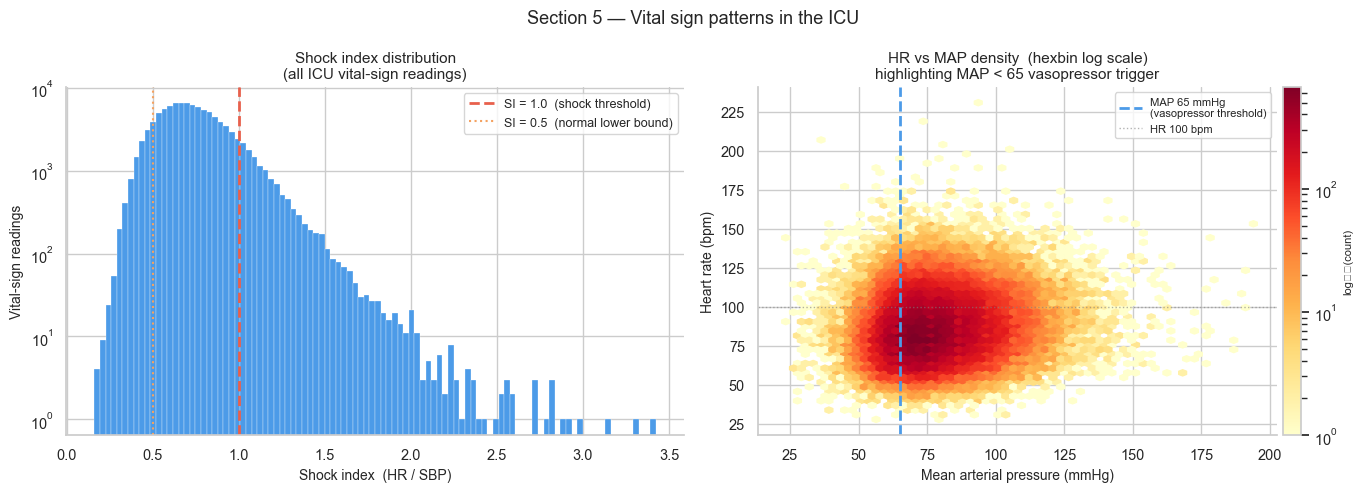

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Section 5 visualisations ───────────────────────────────────────────────
# (a) Shock-index category bar chart
#     — SI = HR / SBP; >1.0 flags haemodynamic compromise
# (b) HR vs MAP 2-D density plot (hexbin)
#     — MAP < 65 threshold is the key vasopressor trigger in septic shock

df_vitals_viz = q("""
    SELECT heart_rate, sbp, mbp, resp_rate, spo2
    FROM mimiciv_derived.vitalsign
    WHERE heart_rate BETWEEN 20 AND 250
      AND sbp        BETWEEN 40 AND 300
      AND mbp        BETWEEN 20 AND 200
    ORDER BY RANDOM()
""", limit=100_000)

if df_vitals_viz.empty:
    print('[SKIP] vitalsign table empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (a) Shock index distribution ─────────────────────────────────────
    ax = axes[0]
    si = (df_vitals_viz['heart_rate'] / df_vitals_viz['sbp']).dropna()
    si = si[(si > 0) & (si < 4)]
    ax.hist(si, bins=100, color='#4C9BE8', edgecolor='white', linewidth=0.2)
    ax.axvline(1.0, color='#E8604C', linewidth=2, linestyle='--',
               label='SI = 1.0  (shock threshold)')
    ax.axvline(0.5, color='#F4A261', linewidth=1.5, linestyle=':',
               label='SI = 0.5  (normal lower bound)')
    ax.set_xlabel('Shock index  (HR / SBP)', fontsize=10)
    ax.set_ylabel('Vital-sign readings', fontsize=10)
    ax.set_title('Shock index distribution\n(all ICU vital-sign readings)',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.set_yscale('log')
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) HR vs MAP hexbin ───────────────────────────────────────────────
    ax = axes[1]
    hb = ax.hexbin(df_vitals_viz['mbp'], df_vitals_viz['heart_rate'],
                   gridsize=60, cmap='YlOrRd', mincnt=1, bins='log')
    cbar = fig.colorbar(hb, ax=ax, pad=0.01)
    cbar.set_label('log₁₀(count)', fontsize=8)
    ax.axvline(65, color='#4C9BE8', linewidth=2, linestyle='--',
               label='MAP 65 mmHg\n(vasopressor threshold)')
    ax.axhline(100, color='gray', linewidth=1, linestyle=':', alpha=0.6,
               label='HR 100 bpm')
    ax.set_xlabel('Mean arterial pressure (mmHg)', fontsize=10)
    ax.set_ylabel('Heart rate (bpm)', fontsize=10)
    ax.set_title('HR vs MAP density  (hexbin log scale)\nhighlighting MAP < 65 vasopressor trigger',
                 fontsize=11)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 5 — Vital sign patterns in the ICU', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 6. Glasgow Coma Scale

**GCS** quantifies level of consciousness:
- Eye response: 1–4
- Verbal response: 1–5 (imputed to 0 for intubated patients — `gcs_unable` flag)
- Motor response: 1–6
- **Total: 3–15** (15 = fully awake; ≤ 8 = severe impairment)

`gcs` provides one row per charted assessment. `first_day_gcs` gives the
**minimum** (worst) GCS in the first 24 h — a direct input to SOFA (CNS
component), SAPS II, OASIS, and APSIII.

In [21]:
# gcs — one row per charted assessment with ETT imputation flag
# Column is gcs_eyes (not gcs_eye); gcs_verbal = 0 indicates intubated patient
display(q("""
    SELECT stay_id, charttime,
           gcs_eyes, gcs_verbal, gcs_motor,
           gcs AS gcs_total,
           gcs_unable
    FROM mimiciv_derived.gcs
    ORDER BY stay_id, charttime
"""))

,stay_id,charttime,gcs_eyes,gcs_verbal,gcs_motor,gcs_total,gcs_unable
0,30000153,2174-09-29 12:45:00,3.000,0.000,5.000,15.000,1
1,30000153,2174-09-29 16:26:00,4.000,0.000,6.000,15.000,1
2,30000153,2174-09-29 17:37:00,4.000,0.000,6.000,15.000,1
3,30000153,2174-09-29 18:00:00,3.000,1.000,5.000,9.000,0
4,30000153,2174-09-29 19:00:00,3.000,1.000,5.000,9.000,0
5,30000153,2174-09-29 20:00:00,3.000,3.000,6.000,12.000,0
6,30000153,2174-09-29 21:00:00,3.000,3.000,6.000,12.000,0
7,30000153,2174-09-29 22:04:00,3.000,3.000,6.000,12.000,0
8,30000153,2174-09-29 23:00:00,3.000,3.000,6.000,12.000,0
9,30000153,2174-09-30 00:00:00,3.000,5.000,6.000,14.000,0


In [22]:
# Distribution of worst first-day GCS
# Low GCS on admission is one of the strongest mortality predictors
display(q("""
    SELECT
        gcs_min,
        COUNT(*) AS n_stays,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM mimiciv_derived.first_day_gcs
    WHERE gcs_min IS NOT NULL
    GROUP BY gcs_min
    ORDER BY gcs_min
""", limit=20))

,gcs_min,n_stays,pct
0,3.000,2440,2.6
1,4.000,371,0.4
2,5.000,264,0.3
3,6.000,867,0.9
4,7.000,1122,1.2
5,8.000,1288,1.4
6,9.000,1472,1.6
7,10.000,2113,2.3
8,11.000,1875,2.0
9,12.000,1958,2.1


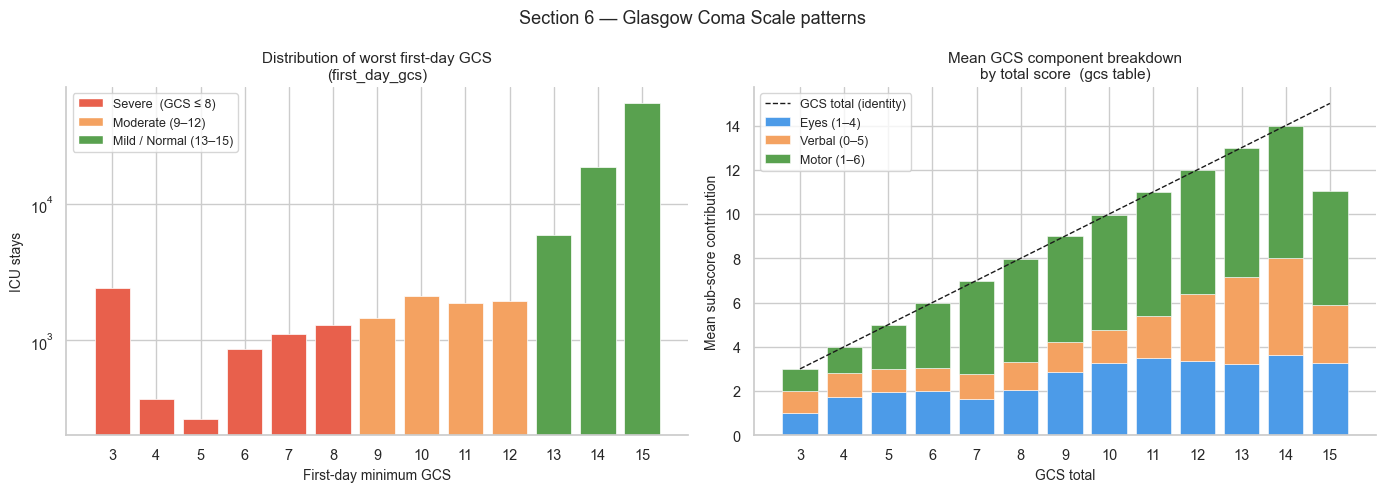

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# ── Section 6 visualisations ───────────────────────────────────────────────
# (a) First-day GCS distribution bar chart split by verbal status
#     — GCS 15 dominates; GCS 3 peak is intubated patients (verbal = 0)
# (b) Component contribution: mean eye / verbal / motor across GCS total values
#     — reveals how each sub-score limits the total

df_gcs_dist = q("""
    SELECT gcs_min, COUNT(*) AS n_stays
    FROM mimiciv_derived.first_day_gcs
    WHERE gcs_min IS NOT NULL
    GROUP BY gcs_min
    ORDER BY gcs_min
""", limit=20)

df_gcs_comp = q("""
    SELECT
        ROUND(gcs) AS gcs_total,
        ROUND(AVG(gcs_eyes)::numeric,   2) AS mean_eyes,
        ROUND(AVG(gcs_verbal)::numeric, 2) AS mean_verbal,
        ROUND(AVG(gcs_motor)::numeric,  2) AS mean_motor,
        COUNT(*) AS n
    FROM mimiciv_derived.gcs
    WHERE gcs IS NOT NULL AND gcs BETWEEN 3 AND 15
    GROUP BY ROUND(gcs)
    ORDER BY ROUND(gcs)
""", limit=15)

if df_gcs_dist.empty:
    print('[SKIP] first_day_gcs empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (a) first-day GCS distribution ────────────────────────────────────
    ax = axes[0]
    x  = df_gcs_dist['gcs_min'].astype(int)
    y  = df_gcs_dist['n_stays'].astype(int)
    colors = ['#E8604C' if v <= 8 else '#F4A261' if v <= 12 else '#59A14F'
              for v in x]
    bars = ax.bar(x, y, color=colors, edgecolor='white', linewidth=0.5)

    # Severity zone legend patches
    from matplotlib.patches import Patch
    handles = [Patch(facecolor='#E8604C', label='Severe  (GCS ≤ 8)'),
               Patch(facecolor='#F4A261', label='Moderate (9–12)'),
               Patch(facecolor='#59A14F', label='Mild / Normal (13–15)')]
    ax.legend(handles=handles, fontsize=9)
    ax.set_xlabel('First-day minimum GCS', fontsize=10)
    ax.set_ylabel('ICU stays', fontsize=10)
    ax.set_title('Distribution of worst first-day GCS\n(first_day_gcs)', fontsize=11)
    ax.set_yscale('log')
    ax.set_xticks(range(3, 16))
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) GCS component stacked bar across total values ─────────────────
    ax = axes[1]
    if not df_gcs_comp.empty:
        x2 = df_gcs_comp['gcs_total'].astype(float)
        eyes   = df_gcs_comp['mean_eyes'].fillna(0).astype(float)
        verbal = df_gcs_comp['mean_verbal'].fillna(0).astype(float)
        motor  = df_gcs_comp['mean_motor'].fillna(0).astype(float)
        ax.bar(x2, eyes,   label='Eyes (1–4)',     color='#4C9BE8',
               edgecolor='white', linewidth=0.4)
        ax.bar(x2, verbal, label='Verbal (0–5)',   color='#F4A261',
               bottom=eyes, edgecolor='white', linewidth=0.4)
        ax.bar(x2, motor,  label='Motor (1–6)',    color='#59A14F',
               bottom=eyes + verbal, edgecolor='white', linewidth=0.4)
        ax.plot(x2, x2, 'k--', linewidth=1, label='GCS total (identity)')
        ax.set_xlabel('GCS total', fontsize=10)
        ax.set_ylabel('Mean sub-score contribution', fontsize=10)
        ax.set_title('Mean GCS component breakdown\nby total score  (gcs table)',
                     fontsize=11)
        ax.legend(fontsize=9)
        ax.set_xticks(range(3, 16))
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 6 — Glasgow Coma Scale patterns', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 7. Acute Kidney Injury (KDIGO Staging)

The **KDIGO** criteria (Kidney Disease: Improving Global Outcomes) define AKI
stages 1–3 based on:
- Creatinine rise relative to baseline (`kdigo_creatinine`)
- Urine output over 6/12/24-h windows (`kdigo_uo`)

`kdigo_stages` combines both into a **combined hourly stage** — the worst of
the two criteria. AKI is the most common ICU complication and is independently
associated with mortality, hospital length of stay, and long-term CKD.

| Stage | Creatinine criterion | Urine output criterion |
|-------|---------------------|------------------------|
| 1 | 1.5–1.9× baseline or +0.3 mg/dL | < 0.5 mL/kg/h for ≥ 6 h |
| 2 | 2.0–2.9× baseline | < 0.5 mL/kg/h for ≥ 12 h |
| 3 | ≥ 3× baseline or start of RRT | < 0.3 mL/kg/h for ≥ 24 h |

In [24]:
# kdigo_stages — combined hourly AKI stage (show only rows where AKI is present)
display(q("""
    SELECT stay_id, charttime,
           aki_stage_creat,
           aki_stage_uo,
           aki_stage
    FROM mimiciv_derived.kdigo_stages
    WHERE aki_stage > 0
    ORDER BY stay_id, charttime
"""))

,stay_id,charttime,aki_stage_creat,aki_stage_uo,aki_stage
0,30000153,2174-09-30 05:00:00,NaN,1.000,1
1,30000153,2174-09-30 06:00:00,NaN,1.000,1
2,30000153,2174-09-30 07:00:00,NaN,1.000,1
3,30000213,2162-06-21 02:45:00,1.000,NaN,1
4,30000213,2162-06-21 03:45:00,1.000,NaN,1
5,30000213,2162-06-21 14:02:00,1.000,NaN,1
6,30000213,2162-06-21 20:43:00,1.000,NaN,1
7,30000213,2162-06-22 04:00:00,1.000,0.000,1
8,30000484,2136-01-15 00:59:00,NaN,1.000,1
9,30000484,2136-01-15 03:00:00,NaN,1.000,1


In [25]:
# Peak AKI stage per ICU stay
# Stage 3 often requires renal replacement therapy (RRT)
display(q("""
    SELECT aki_stage AS peak_aki_stage, COUNT(*) AS n_stays
    FROM (
        SELECT stay_id, MAX(aki_stage) AS aki_stage
        FROM mimiciv_derived.kdigo_stages
        GROUP BY stay_id
    ) t
    GROUP BY aki_stage
    ORDER BY aki_stage
""", limit=10))

,peak_aki_stage,n_stays
0,0,32716
1,1,18870
2,2,27835
3,3,15037


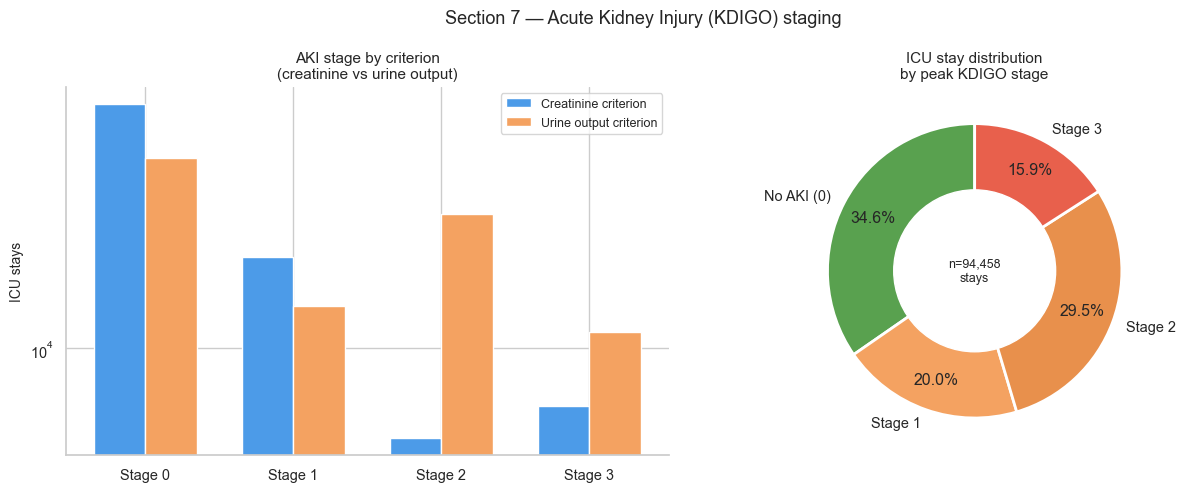

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ── Section 7 visualisations ───────────────────────────────────────────────
# (a) Peak AKI stage per stay — grouped bar showing creatinine vs UO criterion
#     — reveals how much each criterion independently drives AKI staging
# (b) Proportion of ICU stays reaching each KDIGO stage
#     — donut chart for quick teaching communication

df_aki_crit = q("""
    SELECT
        MAX(aki_stage_creat) AS peak_creat_stage,
        MAX(aki_stage_uo)    AS peak_uo_stage,
        MAX(aki_stage)       AS peak_combined
    FROM mimiciv_derived.kdigo_stages
    GROUP BY stay_id
""", limit=200_000)

df_aki_peak = q("""
    SELECT aki_stage AS peak_aki_stage, COUNT(*) AS n_stays
    FROM (
        SELECT stay_id, MAX(aki_stage) AS aki_stage
        FROM mimiciv_derived.kdigo_stages
        GROUP BY stay_id
    ) t
    GROUP BY aki_stage
    ORDER BY aki_stage
""", limit=10)

if df_aki_crit.empty or df_aki_peak.empty:
    print('[SKIP] kdigo_stages empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── (a) Grouped bar: creatinine vs UO criterion per stage ─────────────
    ax = axes[0]
    stages = [0, 1, 2, 3]
    creat_counts = [int((df_aki_crit['peak_creat_stage'].fillna(0).astype(int) == s).sum())
                    for s in stages]
    uo_counts    = [int((df_aki_crit['peak_uo_stage'].fillna(0).astype(int) == s).sum())
                    for s in stages]
    x  = np.arange(len(stages))
    w  = 0.35
    ax.bar(x - w/2, creat_counts, width=w, label='Creatinine criterion',
           color='#4C9BE8', edgecolor='white')
    ax.bar(x + w/2, uo_counts, width=w, label='Urine output criterion',
           color='#F4A261', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Stage {s}' for s in stages])
    ax.set_ylabel('ICU stays', fontsize=10)
    ax.set_title('AKI stage by criterion\n(creatinine vs urine output)', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_yscale('log')
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) Donut — overall AKI prevalence by peak stage ──────────────────
    ax = axes[1]
    stage_labels = ['No AKI (0)', 'Stage 1', 'Stage 2', 'Stage 3']
    stage_colors = ['#59A14F', '#F4A261', '#E8904C', '#E8604C']
    counts = df_aki_peak['n_stays'].astype(int).tolist()
    wedges, texts, autotexts = ax.pie(
        counts, labels=stage_labels, autopct='%1.1f%%',
        colors=stage_colors[:len(counts)],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        startangle=90, pctdistance=0.78)
    # Draw inner circle to make it a donut
    inner = plt.Circle((0, 0), 0.55, color='white')
    ax.add_patch(inner)
    ax.text(0, 0, f'n={sum(counts):,}\nstays', ha='center', va='center',
            fontsize=9)
    ax.set_title('ICU stay distribution\nby peak KDIGO stage', fontsize=11)

    fig.suptitle('Section 7 — Acute Kidney Injury (KDIGO) staging', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 8. Vasopressor Agents

**`vasoactive_agent`** tracks all vasoactive drug infusions by stay and time
window, with one column per drug (norepinephrine, epinephrine, dopamine,
phenylephrine, vasopressin, dobutamine, milrinone).

**`norepinephrine_equivalent_dose`** converts all vasopressor rates to a
common **norepinephrine-equivalent (NEQ) dose** in mcg/kg/min using published
conversion factors. This allows consistent quantification of vasopressor burden
across drugs — the standard approach for:
- Septic shock vasopressor weaning studies
- Defining refractory shock (NEQ > 0.25 mcg/kg/min)
- Pharmacological treatment analyses

In [27]:
# vasoactive_agent — hourly infusion rates by drug
display(q("""
    SELECT stay_id, starttime, endtime,
           norepinephrine, epinephrine, dopamine,
           phenylephrine, vasopressin,
           dobutamine, milrinone
    FROM mimiciv_derived.vasoactive_agent
    WHERE norepinephrine IS NOT NULL OR epinephrine IS NOT NULL
    ORDER BY stay_id, starttime
"""))

,stay_id,starttime,endtime,norepinephrine,epinephrine,dopamine,phenylephrine,vasopressin,dobutamine,milrinone
0,30001446,2186-04-12 09:57:00,2186-04-12 10:53:00,0.040,NaN,NaN,NaN,NaN,NaN,NaN
1,30001446,2186-04-12 10:53:00,2186-04-12 12:45:00,0.080,NaN,NaN,NaN,NaN,NaN,NaN
2,30001446,2186-04-12 12:45:00,2186-04-12 13:55:00,0.060,NaN,NaN,NaN,NaN,NaN,NaN
3,30001446,2186-04-12 13:55:00,2186-04-12 16:10:00,0.040,NaN,NaN,NaN,NaN,NaN,NaN
4,30001446,2186-04-12 16:10:00,2186-04-12 16:13:00,0.040,NaN,NaN,NaN,NaN,NaN,NaN
5,30001446,2186-04-12 17:13:00,2186-04-12 20:00:00,0.040,NaN,NaN,NaN,NaN,NaN,NaN
6,30001446,2186-04-12 20:00:00,2186-04-12 23:24:00,0.030,NaN,NaN,NaN,NaN,NaN,NaN
7,30002654,2154-10-18 01:25:00,2154-10-18 02:35:00,0.351,NaN,NaN,NaN,NaN,NaN,NaN
8,30002654,2154-10-18 02:35:00,2154-10-18 03:47:00,0.250,NaN,NaN,NaN,NaN,NaN,NaN
9,30002654,2154-10-18 03:47:00,2154-10-18 04:41:00,0.200,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# NEQ dose distribution — refractory shock threshold is 0.25 mcg/kg/min
display(q("""
    SELECT
        CASE
            WHEN norepinephrine_equivalent_dose < 0.1  THEN '< 0.10'
            WHEN norepinephrine_equivalent_dose < 0.25 THEN '0.10-0.25'
            WHEN norepinephrine_equivalent_dose < 0.5  THEN '0.25-0.50 (high)'
            ELSE                                            '>= 0.50   (very high / refractory)'
        END AS neq_bucket,
        COUNT(*) AS n_hours
    FROM mimiciv_derived.norepinephrine_equivalent_dose
    WHERE norepinephrine_equivalent_dose IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""", limit=10))

,neq_bucket,n_hours
0,< 0.10,317009
1,0.10-0.25,262453
2,0.25-0.50 (high),132391
3,>= 0.50 (very high / refractory),71760


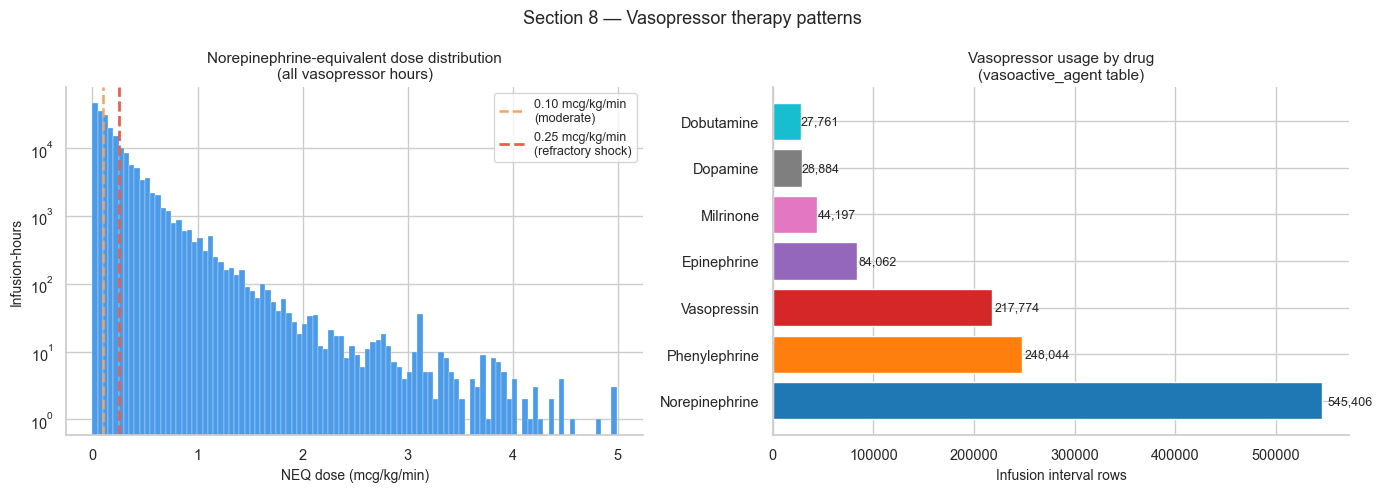

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Section 8 visualisations ───────────────────────────────────────────────
# (a) NEQ dose distribution with refractory shock threshold
#     — key pharmacological surrogate for severity of haemodynamic compromise
# (b) Vasopressor usage breakdown: which drugs appear and how often
#     — norepinephrine dominates; vasopressin is adjunctive; others rare

df_neq_viz = q("""
    SELECT norepinephrine_equivalent_dose AS neq
    FROM mimiciv_derived.norepinephrine_equivalent_dose
    WHERE norepinephrine_equivalent_dose IS NOT NULL
      AND norepinephrine_equivalent_dose > 0
""", limit=200_000)

df_vaso_use = q("""
    SELECT
        COUNT(norepinephrine) FILTER (WHERE norepinephrine IS NOT NULL) AS norepinephrine,
        COUNT(epinephrine)    FILTER (WHERE epinephrine    IS NOT NULL) AS epinephrine,
        COUNT(dopamine)       FILTER (WHERE dopamine       IS NOT NULL) AS dopamine,
        COUNT(phenylephrine)  FILTER (WHERE phenylephrine  IS NOT NULL) AS phenylephrine,
        COUNT(vasopressin)    FILTER (WHERE vasopressin    IS NOT NULL) AS vasopressin,
        COUNT(dobutamine)     FILTER (WHERE dobutamine     IS NOT NULL) AS dobutamine,
        COUNT(milrinone)      FILTER (WHERE milrinone      IS NOT NULL) AS milrinone
    FROM mimiciv_derived.vasoactive_agent
""", limit=1)

if df_neq_viz.empty:
    print('[SKIP] norepinephrine_equivalent_dose empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (a) NEQ dose distribution (log scale) ─────────────────────────────
    ax = axes[0]
    neq = df_neq_viz['neq'].astype(float)
    neq = neq[neq < 5]  # cap extreme outliers
    ax.hist(neq, bins=100, color='#4C9BE8', edgecolor='white', linewidth=0.2)
    ax.axvline(0.1,  color='#F4A261', linewidth=1.8, linestyle='--',
               label='0.10 mcg/kg/min\n(moderate)')
    ax.axvline(0.25, color='#E8604C', linewidth=2,   linestyle='--',
               label='0.25 mcg/kg/min\n(refractory shock)')
    ax.set_xlabel('NEQ dose (mcg/kg/min)', fontsize=10)
    ax.set_ylabel('Infusion-hours', fontsize=10)
    ax.set_title('Norepinephrine-equivalent dose distribution\n(all vasopressor hours)',
                 fontsize=11)
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) Vasopressor usage frequency ───────────────────────────────────
    ax = axes[1]
    if not df_vaso_use.empty:
        drugs  = ['Norepinephrine', 'Epinephrine', 'Dopamine',
                  'Phenylephrine', 'Vasopressin', 'Dobutamine', 'Milrinone']
        cols   = ['norepinephrine', 'epinephrine', 'dopamine',
                  'phenylephrine', 'vasopressin', 'dobutamine', 'milrinone']
        counts = [int(df_vaso_use[c].iloc[0]) for c in cols]
        sorted_pairs = sorted(zip(counts, drugs), reverse=True)
        counts_s, drugs_s = zip(*sorted_pairs)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(drugs_s)))
        bars = ax.barh(drugs_s, counts_s, color=colors, edgecolor='white')
        for bar, val in zip(bars, counts_s):
            ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                    f'{int(val):,}', va='center', fontsize=9)
        ax.set_xlabel('Infusion interval rows', fontsize=10)
        ax.set_title('Vasopressor usage by drug\n(vasoactive_agent table)', fontsize=11)
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 8 — Vasopressor therapy patterns', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 9. Antibiotics

**`antibiotic`** flags each prescription/infusion row in `prescriptions` and
`emar` with the antibiotic name and route. It is the upstream input to
`suspicion_of_infection` (and therefore `sepsis3`).

Direct uses:
- Antibiotic stewardship studies
- Broad-spectrum vs. targeted therapy analyses
- Duration of therapy and de-escalation studies
- Multi-drug resistant organism (MDRO) research

In [30]:
# antibiotic — one row per antibiotic order
display(q("""
    SELECT stay_id, starttime, stoptime, antibiotic, route
    FROM mimiciv_derived.antibiotic
    ORDER BY stay_id, starttime
"""))

,stay_id,starttime,stoptime,antibiotic,route
0,30000484.000,2136-01-14 21:00:00,2136-01-15 16:00:00,Levofloxacin,IV
1,30000484.000,2136-01-14 21:00:00,2136-01-15 20:00:00,Piperacillin-Tazobactam,IV
2,30000484.000,2136-01-14 21:00:00,2136-01-15 20:00:00,Vancomycin,IV
3,30000484.000,2136-01-15 02:00:00,2136-01-16 01:00:00,Piperacillin-Tazobactam,IV
4,30000484.000,2136-01-15 04:00:00,2136-01-16 03:00:00,Vancomycin Oral Liquid,PO
5,30000484.000,2136-01-15 08:00:00,2136-01-17 13:00:00,Vancomycin,IV
6,30000484.000,2136-01-15 12:00:00,2136-01-21 16:00:00,Piperacillin-Tazobactam,IV
7,30000484.000,2136-01-15 12:00:00,2136-01-18 08:00:00,Vancomycin Oral Liquid,PO
8,30000484.000,2136-01-15 17:00:00,2136-01-17 14:00:00,Tobramycin Sulfate,IV
9,30000484.000,2136-01-15 20:00:00,2136-01-14 21:00:00,Vancomycin,IV


In [31]:
# Most frequently administered antibiotics
display(q("""
    SELECT antibiotic, COUNT(*) AS n_orders
    FROM mimiciv_derived.antibiotic
    GROUP BY antibiotic
    ORDER BY n_orders DESC
""", limit=15))

,antibiotic,n_orders
0,Vancomycin,229577
1,CefePIME,73881
2,Piperacillin-Tazobactam,51631
3,Ciprofloxacin HCl,46317
4,CefTRIAXone,45986
5,MetRONIDAZOLE (FLagyl),38128
6,CefazoLIN,38086
7,MetroNIDAZOLE,34005
8,CeFAZolin,30953
9,Levofloxacin,30099


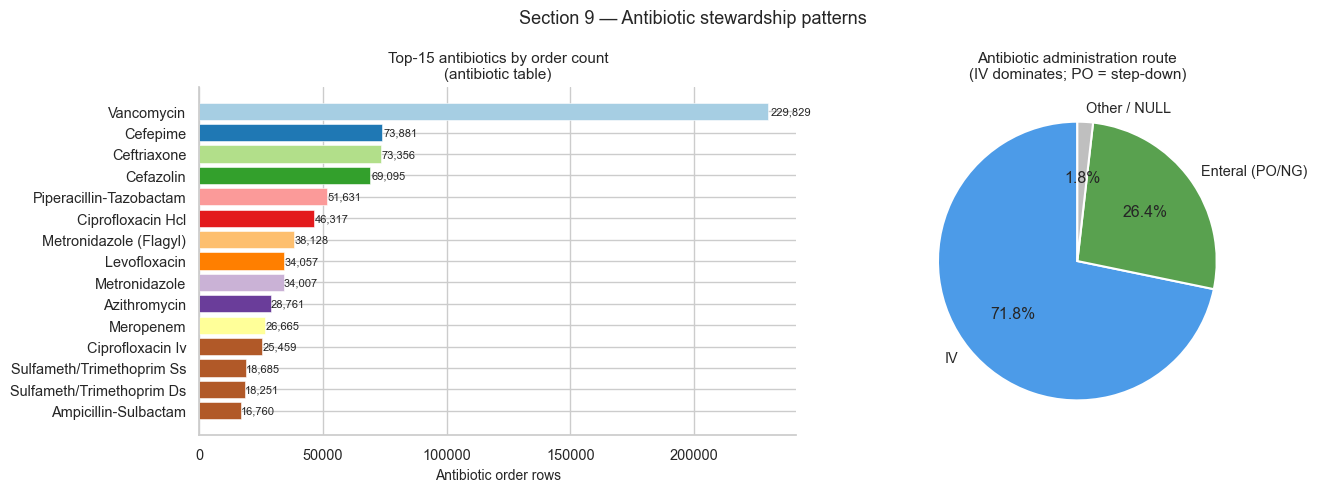

In [32]:
import matplotlib.pyplot as plt
import re

# ── Section 9 visualisations ───────────────────────────────────────────────
# (a) Top-15 antibiotics horizontal bar
#     — identifies empiric backbone (vancomycin + piperacillin-tazobactam)
#     — mixed-case drug names normalised for display
# (b) Administration route breakdown (IV vs PO vs other)
#     — most ICU antibiotics are IV; PO indicates de-escalation / step-down

df_abx_top = q("""
    SELECT LOWER(antibiotic) AS drug, COUNT(*) AS n_orders
    FROM mimiciv_derived.antibiotic
    GROUP BY LOWER(antibiotic)
    ORDER BY n_orders DESC
""", limit=15)

df_abx_route = q("""
    SELECT
        CASE
            WHEN UPPER(route) IN ('IV', 'IVPB', 'IV DRIP', 'IVSS') THEN 'IV'
            WHEN UPPER(route) IN ('PO', 'PO/NG', 'NG', 'GT', 'PO OR NG',
                                  'PO/NG/GT') THEN 'Enteral (PO/NG)'
            ELSE 'Other / NULL'
        END AS route_group,
        COUNT(*) AS n
    FROM mimiciv_derived.antibiotic
    GROUP BY 1
    ORDER BY n DESC
""", limit=10)

if df_abx_top.empty:
    print('[SKIP] antibiotic table empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (a) Top-15 antibiotics horizontal bar ─────────────────────────────
    ax = axes[0]
    # Capitalise drug names cleanly
    drugs  = [re.sub(r'[a-z]+', lambda m: m.group(0).capitalize(),
                     d).strip() for d in df_abx_top['drug']]
    counts = df_abx_top['n_orders'].astype(int).tolist()
    colors = plt.cm.Paired(range(len(drugs)))
    bars = ax.barh(drugs[::-1], counts[::-1], color=colors[::-1],
                   edgecolor='white', linewidth=0.4)
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
                f'{int(val):,}', va='center', fontsize=8)
    ax.set_xlabel('Antibiotic order rows', fontsize=10)
    ax.set_title('Top-15 antibiotics by order count\n(antibiotic table)', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) Route breakdown pie ────────────────────────────────────────────
    ax = axes[1]
    if not df_abx_route.empty:
        route_labels = df_abx_route['route_group'].tolist()
        route_counts = df_abx_route['n'].astype(int).tolist()
        route_colors = ['#4C9BE8', '#59A14F', '#BFBFBF']
        ax.pie(route_counts, labels=route_labels, autopct='%1.1f%%',
               colors=route_colors[:len(route_labels)],
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
               startangle=90)
    ax.set_title('Antibiotic administration route\n(IV dominates; PO = step-down)',
                 fontsize=11)

    fig.suptitle('Section 9 — Antibiotic stewardship patterns', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 10. Charlson Comorbidity Index

**`charlson`** assigns a weighted comorbidity score to each hospital admission
by scanning ICD-9/10 diagnosis codes.

Comorbidity categories and weights:

| Weight | Conditions |
|--------|------------|
| 1 | MI, CHF, PVD, cerebrovascular disease, dementia, COPD, connective tissue disease, peptic ulcer, mild liver disease, diabetes without complications |
| 2 | Diabetes with complications, hemiplegia/paraplegia, renal disease, any malignancy |
| 3 | Moderate/severe liver disease |
| 6 | Metastatic solid tumour, AIDS |

CCI is widely used to **control for baseline health** in outcome studies and
to stratify cohorts by comorbidity burden.

In [33]:
# charlson — one row per hospital admission
display(q("""
    SELECT hadm_id,
           myocardial_infarct,
           congestive_heart_failure,
           chronic_pulmonary_disease,
           diabetes_without_cc,
           diabetes_with_cc,
           renal_disease,
           malignant_cancer,
           charlson_comorbidity_index AS cci
    FROM mimiciv_derived.charlson
    ORDER BY cci DESC
"""))

,hadm_id,myocardial_infarct,congestive_heart_failure,chronic_pulmonary_disease,diabetes_without_cc,diabetes_with_cc,renal_disease,malignant_cancer,cci
0,21459303,1,1,0,0,1,1,0,21
1,22807401,1,1,1,0,1,1,1,20
2,23881981,0,0,0,0,1,1,1,19
3,21095840,1,1,1,0,1,1,1,19
4,26847816,1,1,0,1,1,1,0,19
5,22339295,0,1,0,0,1,1,0,19
6,26890095,0,0,0,0,0,1,1,19
7,24557157,0,0,0,1,0,1,1,19
8,26886218,1,1,0,0,1,1,1,19
9,26007217,1,1,0,0,1,1,1,19


In [34]:
# CCI distribution — most ICU patients have CCI >= 2
display(q("""
    SELECT charlson_comorbidity_index AS cci,
           COUNT(*) AS n_admissions
    FROM mimiciv_derived.charlson
    GROUP BY cci
    ORDER BY cci
""", limit=20))

,cci,n_admissions
0,0,106661
1,1,60229
2,2,58864
3,3,58180
4,4,62179
5,5,52870
6,6,43413
7,7,34458
8,8,26498
9,9,18820


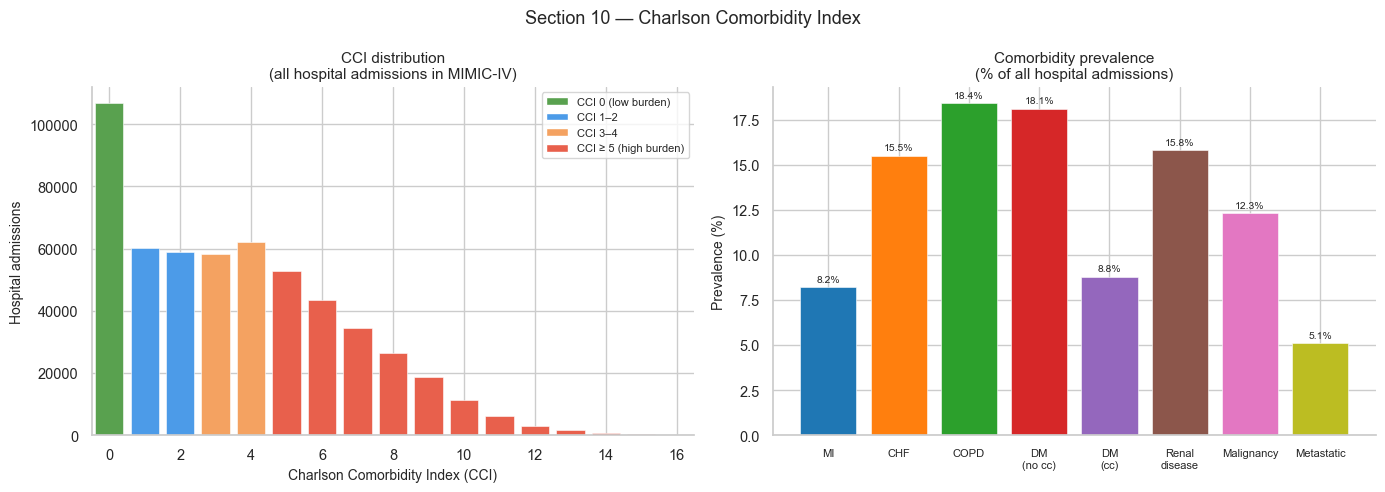

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ── Section 10 visualisations ──────────────────────────────────────────────
# (a) CCI distribution bar chart with expected 1-year mortality overlay
#     — shows the relationship between comorbidity burden and prognosis
# (b) Comorbidity co-occurrence: top conditions and their prevalence
#     — helps identify common comorbidity combinations in the ICU

# Published Charlson 1-year mortality estimates (Charlson 1994)
_cci_mortality = {0: 0.12, 1: 0.26, 2: 0.52, 3: 0.85}  # extrapolated beyond

df_cci_dist = q("""
    SELECT charlson_comorbidity_index AS cci, COUNT(*) AS n_admissions
    FROM mimiciv_derived.charlson
    GROUP BY cci
    ORDER BY cci
""", limit=25)

df_comorbid = q("""
    SELECT
        ROUND(100.0 * AVG(myocardial_infarct)::numeric, 1)        AS mi,
        ROUND(100.0 * AVG(congestive_heart_failure)::numeric, 1)  AS chf,
        ROUND(100.0 * AVG(chronic_pulmonary_disease)::numeric, 1) AS copd,
        ROUND(100.0 * AVG(diabetes_without_cc)::numeric, 1)       AS dm_nocc,
        ROUND(100.0 * AVG(diabetes_with_cc)::numeric, 1)          AS dm_cc,
        ROUND(100.0 * AVG(renal_disease)::numeric, 1)             AS renal,
        ROUND(100.0 * AVG(malignant_cancer)::numeric, 1)          AS cancer,
        ROUND(100.0 * AVG(metastatic_solid_tumor)::numeric, 1)    AS metastatic
    FROM mimiciv_derived.charlson
""", limit=1)

if df_cci_dist.empty:
    print('[SKIP] charlson table empty')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── (a) CCI distribution with risk colour bands ────────────────────────
    ax = axes[0]
    cci    = df_cci_dist['cci'].astype(int)
    counts = df_cci_dist['n_admissions'].astype(int)
    max_cci_show = min(int(cci.max()), 16)
    colors = ['#59A14F' if c == 0 else '#4C9BE8' if c <= 2
              else '#F4A261' if c <= 4 else '#E8604C' for c in cci]
    ax.bar(cci, counts, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Charlson Comorbidity Index (CCI)', fontsize=10)
    ax.set_ylabel('Hospital admissions', fontsize=10)
    ax.set_title('CCI distribution\n(all hospital admissions in MIMIC-IV)',
                 fontsize=11)
    ax.set_xlim(-0.5, max_cci_show + 0.5)
    from matplotlib.patches import Patch
    handles = [Patch(facecolor='#59A14F', label='CCI 0 (low burden)'),
               Patch(facecolor='#4C9BE8', label='CCI 1–2'),
               Patch(facecolor='#F4A261', label='CCI 3–4'),
               Patch(facecolor='#E8604C', label='CCI ≥ 5 (high burden)')]
    ax.legend(handles=handles, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) Comorbidity prevalence bar chart ───────────────────────────────
    ax = axes[1]
    if not df_comorbid.empty:
        conditions = ['MI', 'CHF', 'COPD', 'DM\n(no cc)', 'DM\n(cc)',
                      'Renal\ndisease', 'Malignancy', 'Metastatic']
        col_keys   = ['mi', 'chf', 'copd', 'dm_nocc', 'dm_cc',
                      'renal', 'cancer', 'metastatic']
        prevalence = [float(df_comorbid[c].iloc[0]) for c in col_keys]
        x = np.arange(len(conditions))
        bar_colors = plt.cm.tab10(np.linspace(0, 0.8, len(conditions)))
        ax.bar(x, prevalence, color=bar_colors, edgecolor='white', linewidth=0.4)
        ax.set_xticks(x)
        ax.set_xticklabels(conditions, fontsize=8)
        ax.set_ylabel('Prevalence (%)', fontsize=10)
        ax.set_title('Comorbidity prevalence\n(% of all hospital admissions)',
                     fontsize=11)
        for xi, val in zip(x, prevalence):
            ax.text(xi, val + 0.3, f'{val:.1f}%', ha='center', fontsize=7.5)
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 10 — Charlson Comorbidity Index', fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 11. First-Day Summary Tables

`first_day_*` tables aggregate the **worst (or most relevant) value** of each
measurement during the first 24 hours of an ICU stay.

These are the **building blocks of admission-severity feature matrices**: a
single join across these tables produces a flat, analysis-ready row per patient.

| Table | What it captures |
|-------|------------------|
| `first_day_vitalsign` | Min/max of HR, BP, RR, temp, SpO₂ |
| `first_day_lab` | Worst creatinine, BUN, CBC, coags |
| `first_day_bg` | Worst pH, PaO₂, PaCO₂ from blood gas |
| `first_day_bg_art` | Arterial blood gas only |
| `first_day_gcs` | Minimum GCS |
| `first_day_sofa` | SOFA components at 24 h |
| `first_day_urine_output` | Total urine output in first 24 h |
| `first_day_weight` | First weight measurement |
| `first_day_height` | First height measurement |
| `first_day_rrt` | Whether renal replacement therapy was started |

In [36]:
# first_day_vitalsign — worst vital signs in first 24 h
display(q("""
    SELECT stay_id,
           heart_rate_min, heart_rate_max,
           sbp_min, sbp_max,
           mbp_min,
           resp_rate_min, resp_rate_max,
           spo2_min,
           temperature_min
    FROM mimiciv_derived.first_day_vitalsign
    ORDER BY mbp_min NULLS LAST
"""))

,stay_id,heart_rate_min,heart_rate_max,sbp_min,sbp_max,mbp_min,resp_rate_min,resp_rate_max,spo2_min,temperature_min
0,35746627,73.000,90.000,88.000,136.000,0.830,16.000,33.000,92.000,35.33
1,33818777,63.000,97.000,94.000,162.000,1.000,10.000,22.000,96.000,None
2,39436744,65.000,85.000,94.000,125.000,1.000,14.000,36.000,88.000,36.50
3,36645118,108.000,129.000,123.000,156.000,1.000,12.000,27.000,94.000,36.83
4,39023071,95.000,170.000,63.000,133.000,1.000,10.000,35.000,88.000,36.33
5,39594891,73.000,93.000,161.000,198.000,1.000,19.000,30.000,93.000,36.22
6,30423421,64.000,90.000,84.000,126.000,1.000,4.000,20.000,93.000,36.56
7,34161336,30.000,110.000,18.000,162.000,1.000,18.000,37.000,83.000,34.44
8,37292918,49.000,65.000,93.000,153.000,1.000,8.000,18.000,96.000,36.50
9,31517631,47.000,81.000,90.000,155.000,1.000,9.000,28.000,78.000,35.33


In [37]:
# first_day_lab — worst lab values in first 24 h
# Note: column is platelets_min/platelets_max (plural), not platelet_min
display(q("""
    SELECT stay_id,
           creatinine_max,
           bun_max,
           wbc_min, wbc_max,
           hemoglobin_min,
           platelets_min,
           inr_max
    FROM mimiciv_derived.first_day_lab
    ORDER BY creatinine_max DESC NULLS LAST
"""))

,stay_id,creatinine_max,bun_max,wbc_min,wbc_max,hemoglobin_min,platelets_min,inr_max
0,32498311,80.000,81.000,5.300,19.200,8.800,112.000,1.200
1,37964598,62.500,279.000,8.500,10.500,6.300,103.000,1.200
2,38400142,43.000,219.000,6.800,11.200,8.800,153.000,1.400
3,37538188,41.700,184.000,4.900,7.400,10.000,239.000,1.200
4,36944203,38.300,196.000,7.100,11.200,5.400,134.000,1.100
5,33689234,36.400,69.000,7.000,9.500,12.300,149.000,1.200
6,32204925,35.600,217.000,9.100,12.500,10.900,249.000,1.100
7,32682790,35.000,111.000,7.000,8.500,5.200,158.000,1.100
8,36120675,33.200,156.000,7.800,8.200,8.000,138.000,1.200
9,39162813,32.700,155.000,4.500,4.700,9.900,228.000,1.100


In [38]:
# first_day_sofa — 24-h SOFA components used by sepsis3
# Column names are plain (sofa, respiration, ...) not sofa_24hours
display(q("""
    SELECT stay_id,
           sofa        AS sofa_24h,
           respiration AS resp,
           coagulation AS coag,
           liver,
           cardiovascular AS cardio,
           cns,
           renal
    FROM mimiciv_derived.first_day_sofa
    ORDER BY sofa DESC NULLS LAST
"""))

,stay_id,sofa_24h,resp,coag,liver,cardio,cns,renal
0,38430513,23,4.000,3.000,4.000,4.000,4.000,4.000
1,37603649,23,4.000,3.000,4.000,4.000,4.000,4.000
2,32713725,22,4.000,4.000,2.000,4.000,4.000,4.000
3,38466229,22,4.000,3.000,3.000,4.000,4.000,4.000
4,32128372,22,4.000,3.000,3.000,4.000,4.000,4.000
5,30106638,22,4.000,3.000,3.000,4.000,4.000,4.000
6,31613027,22,4.000,4.000,3.000,4.000,3.000,4.000
7,34562436,22,4.000,3.000,3.000,4.000,4.000,4.000
8,34409336,22,4.000,3.000,3.000,4.000,4.000,4.000
9,32050446,22,4.000,3.000,4.000,4.000,4.000,3.000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Section 11 visualisations ──────────────────────────────────────────────
# Correlation heatmap of the first-day feature matrix
# — joins first_day_vitalsign, first_day_lab, first_day_sofa, sapsii
# — shows which features cluster together and which provide independent signal
# — this is the exact feature matrix used as input to prognostic ML models

df_fd = q("""
    SELECT
        fv.heart_rate_max,
        fv.mbp_min,
        fv.resp_rate_max,
        fv.spo2_min,
        fv.temperature_min,
        fl.creatinine_max,
        fl.bun_max,
        fl.wbc_max,
        fl.hemoglobin_min,
        fl.platelets_min,
        fl.inr_max,
        fg.gcs_min,
        fs.sofa    AS sofa_24h,
        sp.sapsii
    FROM mimiciv_derived.first_day_vitalsign fv
    JOIN mimiciv_derived.first_day_lab        fl USING (stay_id)
    JOIN mimiciv_derived.first_day_gcs        fg USING (stay_id)
    JOIN mimiciv_derived.first_day_sofa       fs USING (stay_id)
    JOIN mimiciv_derived.sapsii               sp USING (stay_id)
""", limit=200_000)

if df_fd.empty:
    print('[SKIP] first-day tables empty')
else:
    df_corr = df_fd.apply(pd.to_numeric, errors='coerce')
    df_corr = df_corr.dropna(thresh=int(len(df_corr) * 0.3), axis=1)
    corr    = df_corr.corr()

    pretty_names = {
        'heart_rate_max':  'HR max',
        'mbp_min':         'MAP min',
        'resp_rate_max':   'RR max',
        'spo2_min':        'SpO2 min',       # plain ASCII — subscript glyphs unsupported
        'temperature_min': 'Temp min',
        'creatinine_max':  'Creatinine max',
        'bun_max':         'BUN max',
        'wbc_max':         'WBC max',
        'hemoglobin_min':  'Hgb min',
        'platelets_min':   'Platelets min',
        'inr_max':         'INR max',
        'gcs_min':         'GCS min',
        'sofa_24h':        'SOFA 24h',
        'sapsii':          'SAPS II',
    }
    corr.rename(index=pretty_names, columns=pretty_names, inplace=True)

    fig, ax = plt.subplots(figsize=(11, 9))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={'fontsize': 8}, ax=ax,
                cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
    ax.set_title('First-day feature correlation matrix\n'
                 '(vitals + labs + GCS + SOFA + SAPS II)',
                 fontsize=12, pad=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()
    print('Strong positive correlations (r > 0.6) highlight feature redundancy.')
    print('Strong negative correlations (e.g. GCS down vs SOFA up) confirm clinical intuition.')

---
## 12. Septic Shock Cohort Example

This query assembles a **flat feature table** for a septic shock analysis:
ICU stays meeting Sepsis-3 criteria that also received vasopressors.

For each stay it collects:
- Demographics (`icustay_detail`)
- Comorbidity burden (`charlson`)
- Admission severity (`sapsii`)
- 24-h organ dysfunction (`first_day_sofa`)
- Worst haemodynamics (`first_day_vitalsign`)
- Worst renal function (`first_day_lab`)
- Peak vasopressor dose (`norepinephrine_equivalent_dose`)
- Outcome: in-hospital mortality (`icustay_detail.hospital_expire_flag`)

This is the **typical starting point for a prognostic model** in MIMIC-IV.
With row-limited data the cohort may be small, but the join pattern scales
to the full 75 000-patient dataset.

In [40]:
display(q("""
    SELECT
        s3.stay_id,
        d.gender,
        ROUND(d.admission_age::numeric, 0)       AS age,
        ch.charlson_comorbidity_index            AS cci,
        sp.sapsii,
        ROUND(sp.sapsii_prob::numeric, 3)        AS sapsii_mort_prob,
        fs.sofa                                  AS sofa_24h,
        fv.mbp_min                               AS min_map_day1,
        fl.creatinine_max                        AS max_creat_day1,
        ROUND(ne.norepinephrine_equivalent_dose::numeric, 3) AS peak_neq,
        d.hospital_expire_flag                   AS died_in_hospital
    FROM mimiciv_derived.sepsis3        s3
    JOIN mimiciv_derived.icustay_detail d  USING (stay_id)
    JOIN mimiciv_derived.charlson       ch USING (hadm_id)
    JOIN mimiciv_derived.sapsii         sp USING (stay_id)
    JOIN mimiciv_derived.first_day_sofa fs USING (stay_id)
    JOIN mimiciv_derived.first_day_vitalsign fv USING (stay_id)
    JOIN mimiciv_derived.first_day_lab  fl USING (stay_id)
    JOIN (
        SELECT stay_id, MAX(norepinephrine_equivalent_dose) AS norepinephrine_equivalent_dose
        FROM mimiciv_derived.norepinephrine_equivalent_dose
        GROUP BY stay_id
    ) ne USING (stay_id)
    ORDER BY sapsii DESC
""", limit=20))

,stay_id,gender,age,cci,sapsii,sapsii_mort_prob,sofa_24h,min_map_day1,max_creat_day1,peak_neq,died_in_hospital
0,31949871,F,92,5,115,0.996,20,19.000,1.300,0.393,1
1,32128372,F,75,8,115,0.996,22,27.000,1.000,0.501,0
2,36758013,F,69,7,115,0.996,19,55.000,3.300,3.868,1
3,34786631,F,56,8,110,0.994,21,45.000,1.900,0.206,1
4,35042608,M,71,5,108,0.992,18,26.000,2.500,1.133,1
5,37257840,F,63,6,108,0.992,21,40.000,1.600,1.224,1
6,37686710,M,63,8,108,0.992,18,32.000,4.500,1.439,1
7,30499586,M,81,9,107,0.992,17,29.000,5.500,0.400,1
8,30106638,F,76,7,107,0.992,22,33.000,3.400,2.320,1
9,38280256,M,68,8,107,0.992,16,37.000,2.300,0.646,1


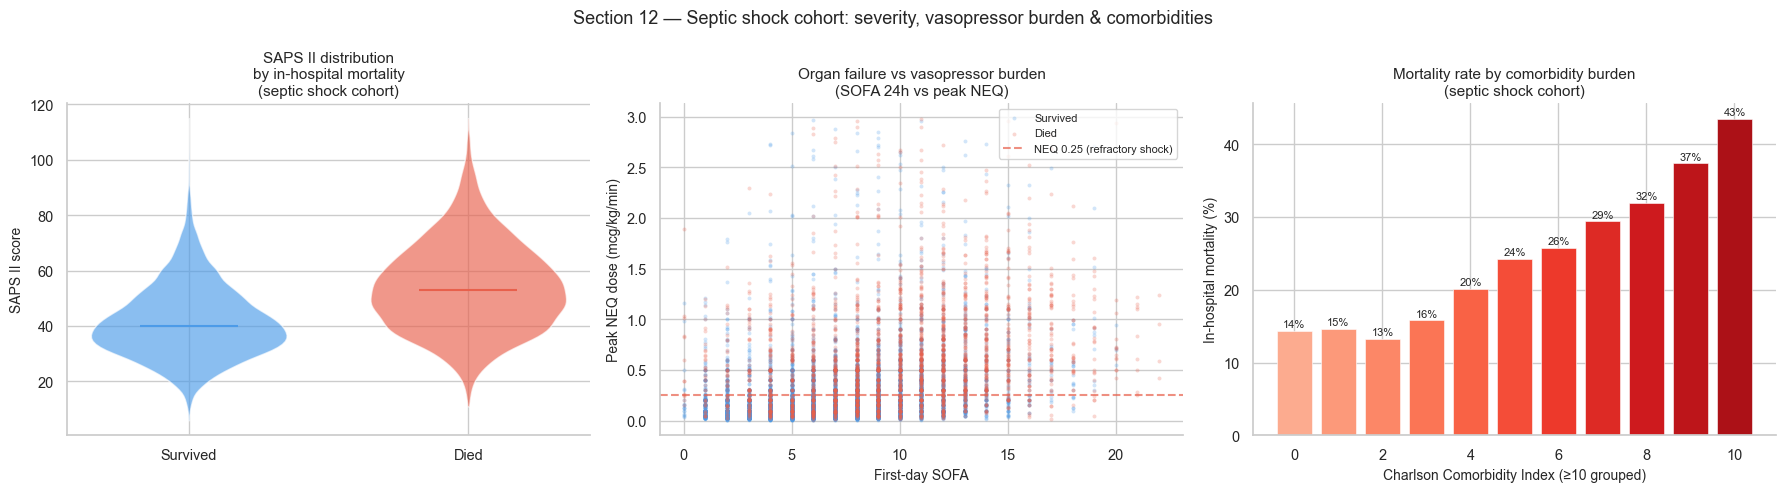

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Section 12 visualisations ──────────────────────────────────────────────
# Visualise the assembled septic shock cohort feature matrix.
# (a) SAPS II vs in-hospital mortality — confirms score discriminates survivors
# (b) Peak NEQ dose vs first-day SOFA — vasopressor burden rises with severity
# (c) CCI vs mortality rate — baseline comorbidities compound critical illness

df_cohort_viz = q("""
    SELECT
        sp.sapsii,
        ROUND(sp.sapsii_prob::numeric, 4) AS sapsii_prob,
        fs.sofa                            AS sofa_24h,
        ch.charlson_comorbidity_index      AS cci,
        ne.peak_neq,
        d.hospital_expire_flag             AS died,
        d.admission_age                    AS age
    FROM mimiciv_derived.sepsis3        s3
    JOIN mimiciv_derived.icustay_detail d  USING (stay_id)
    JOIN mimiciv_derived.charlson       ch USING (hadm_id)
    JOIN mimiciv_derived.sapsii         sp USING (stay_id)
    JOIN mimiciv_derived.first_day_sofa fs USING (stay_id)
    JOIN (
        SELECT stay_id, MAX(norepinephrine_equivalent_dose) AS peak_neq
        FROM mimiciv_derived.norepinephrine_equivalent_dose
        GROUP BY stay_id
    ) ne USING (stay_id)
    WHERE sp.sapsii IS NOT NULL
""", limit=200_000)

if df_cohort_viz.empty:
    print('[SKIP] cohort tables empty')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── (a) SAPS II by mortality — violin plot ────────────────────────────
    ax = axes[0]
    for died, label, color in [(0, 'Survived', '#4C9BE8'), (1, 'Died', '#E8604C')]:
        subset = df_cohort_viz[df_cohort_viz['died'] == died]['sapsii'].dropna()
        parts = ax.violinplot([subset], positions=[died], widths=0.7,
                               showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.65)
        parts['cmedians'].set_colors(color)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Survived', 'Died'])
    ax.set_ylabel('SAPS II score', fontsize=10)
    ax.set_title('SAPS II distribution\nby in-hospital mortality\n(septic shock cohort)',
                 fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (b) Peak NEQ dose vs first-day SOFA ───────────────────────────────
    ax = axes[1]
    sample = df_cohort_viz[['sofa_24h', 'peak_neq', 'died']].dropna()
    sample = sample[sample['peak_neq'] < 3]  # clip extreme outliers
    sample = sample.sample(min(10_000, len(sample)), random_state=42)
    for died, label, color in [(0, 'Survived', '#4C9BE8'), (1, 'Died', '#E8604C')]:
        s = sample[sample['died'] == died]
        ax.scatter(s['sofa_24h'], s['peak_neq'], alpha=0.25, s=8,
                   color=color, label=label, linewidths=0)
    ax.axhline(0.25, color='#E8604C', linewidth=1.5, linestyle='--', alpha=0.7,
               label='NEQ 0.25 (refractory shock)')
    ax.set_xlabel('First-day SOFA', fontsize=10)
    ax.set_ylabel('Peak NEQ dose (mcg/kg/min)', fontsize=10)
    ax.set_title('Organ failure vs vasopressor burden\n(SOFA 24h vs peak NEQ)',
                 fontsize=11)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # ── (c) Mortality rate by CCI bin ──────────────────────────────────────
    ax = axes[2]
    df_cohort_viz['cci_bin'] = df_cohort_viz['cci'].clip(0, 10).astype(int)
    cci_mort = (df_cohort_viz.groupby('cci_bin')['died']
                .agg(['mean', 'count']).reset_index())
    cci_mort = cci_mort[cci_mort['count'] >= 30]  # only show stable estimates
    ax.bar(cci_mort['cci_bin'],
           cci_mort['mean'] * 100,
           color=plt.cm.Reds(np.linspace(0.3, 0.85, len(cci_mort))),
           edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Charlson Comorbidity Index (≥10 grouped)', fontsize=10)
    ax.set_ylabel('In-hospital mortality (%)', fontsize=10)
    ax.set_title('Mortality rate by comorbidity burden\n(septic shock cohort)',
                 fontsize=11)
    for _, row in cci_mort.iterrows():
        ax.text(row['cci_bin'], row['mean'] * 100 + 0.5,
                f"{row['mean']*100:.0f}%", ha='center', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle('Section 12 — Septic shock cohort: severity, vasopressor burden & comorbidities',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Next Steps

- **Validate your data**: `uv run python test_mimic.py`
- **Run the full pipeline again** (if needed): `uv run python build_mimic.py`
- **Explore more concepts**: see `mimic-code/mimic-iv/concepts_postgres/` for all SQL sources
- **Close the connection** when done:

In [42]:
conn.close()
print('Connection closed.')

Connection closed.
